# Geo-Nexus v3.2 — DAPT Final, Persistent Artifacts & Epoch-Resume, 6664-Pair Run

## Purpose

This notebook performs the P2 Maharashtra Domain-Adaptive Pretraining (DAPT) stage using the locked Geo-Nexus v3.2 training protocol:

- **6,664** unlabeled bi-temporal Pune + Satara pairs
- **17-channel** inputs at **128×128**
- SSL4EO-S12 Sentinel-2 optical foundation weights
- BigEarthNet Sentinel-1 VV/VH foundation weights
- DeCUR + weighted temporal InfoNCE
- **100 epochs**, batch size **96**, AMP
- backbone LR `3e-5`, projector/head LR `3e-4`
- 5-epoch linear warm-up followed by cosine decay

## Independent review

The reviewer feedback is **substantially correct on the architecture locks**. The attached architecture and notebook agree on the corpus size, 17-channel tensor contract, 100-epoch DAPT schedule, learning-rate separation, warm-up, DeCUR, temporal loss, synthetic occlusion, stem gate and encoder-only downstream transfer.

One operational gap remained: recovery depended on a 10-epoch checkpoint boundary. This revision removes that dependency and overwrites the **latest full training-state checkpoint after every completed epoch**.

The revision also adds:

- epoch/100 progress and percentage
- current epoch duration
- recent median and mean epoch duration
- session elapsed and remaining wall time
- remaining epochs and optimizer steps
- estimated remaining training time
- projected training finish time
- projected total training time
- private Kaggle artifact Dataset publication at the end of each session
- final encoder, full model, DeCUR state, source, diagnostics, environment and SHA256 artifacts after epoch 100

## Repository reference

Project repository supplied for this project:

`https://github.com/Sumit07125/earth-observation-change-detection`

The current environment could not independently fetch that repository, so this notebook does not claim repository-derived facts beyond the supplied URL. The implementation review is based on the attached project architecture/notebook sources.

## Kaggle persistence

Kaggle documents that files under `/kaggle/working` can be retained as Notebook outputs and reused later, that Notebook Outputs can be turned into Datasets, and that successful **Save & Run All** runs have a 12-hour maximum with up to 20 GB of notebook output. This notebook therefore keeps one bounded latest checkpoint and publishes a private artifact Dataset at session end.

## Execution order

1. Runtime + input discovery
2. Source bootstrap + compile/import gates
3. Foundation weights + exact 6,664-pair gate + smoke test
4. 100-epoch DAPT + every-epoch checkpoint + live timing
5. Training curves + runtime diagnostics
6. Post-DAPT t-SNE
7. Integrity summary
8. Persistent artifact packaging
9. Private Kaggle Dataset publish/update
10. Completion report

The notebook stops immediately when a required integrity gate fails.


KAGGLE INPUT DISCOVERY
/kaggle/input/datasets

Resolved DAPT data root:
/kaggle/input/datasets/sumit07125/geonexus-mh-v3

Resolved foundation-weights root:
/kaggle/input/datasets/sumit07125/ssl4eo-weights

DAPT files:
  norm_stats_trainonly.json        |      0.00 MiB
  pune_meta.json                   |      0.53 MiB
  pune_train.npy                   |   3522.19 MiB
  satara_meta.json                 |      0.54 MiB
  satara_train.npy                 |   3558.31 MiB

Foundation weights:
  resnet18_s1_bigearthnet.pth      |     42.73 MiB
  resnet18_s2c_moco.pth            |     42.83 MiB

RUNTIME GATE
GPUs available: 2
Using device: cuda
GPU 0: Tesla T4
GPU 1: Tesla T4

INPUT + CORPUS GATES: PASS
Pune shape   : (3315, 2, 17, 128, 128)
Satara shape : (3349, 2, 17, 128, 128)
Pune pairs   : 3315
Satara pairs : 3349
Total DAPT   : 6664
PASS: DAPT corpus contains exactly 6664 pairs.

Configuration:
{
  "epochs": 100,
  "batch_size": 96,
  "lr_backbone": 3e-05,
  "lr_head": 0.0003,
  "weigh

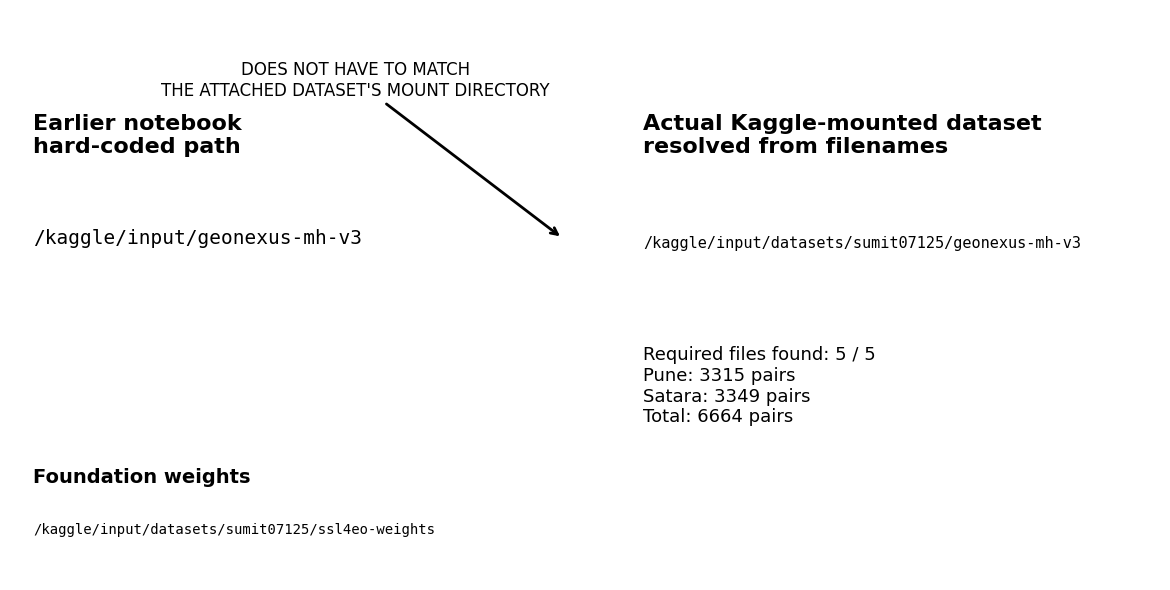


Diagnostic image saved to:
/kaggle/working/geonexus_v3_2_dapt_6664_path_diagnostic.png


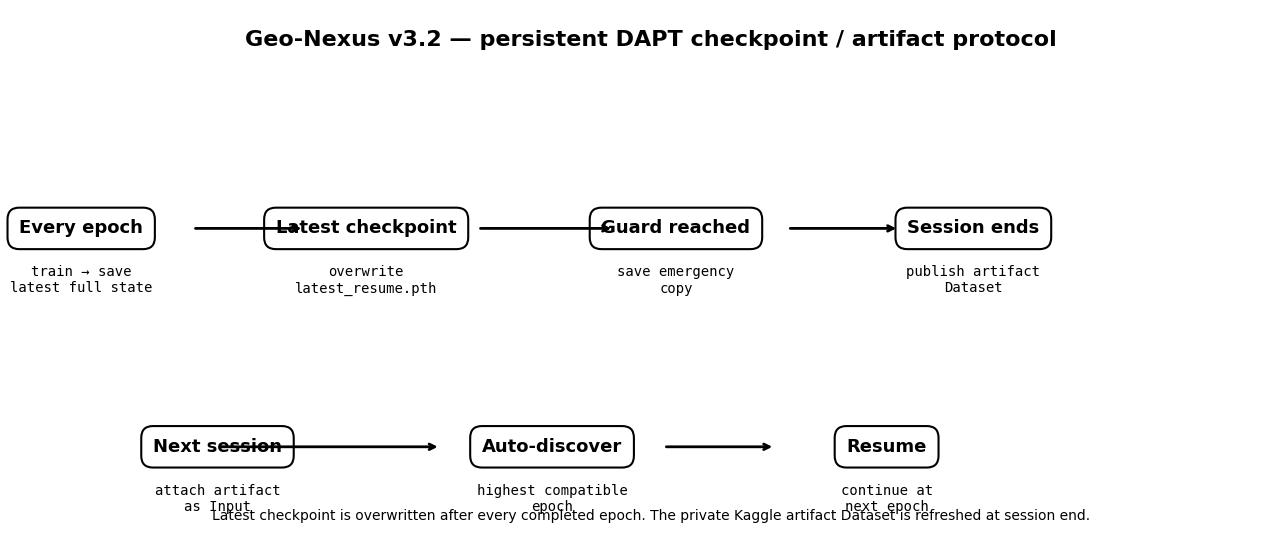

Checkpoint workflow image saved to:
/kaggle/working/geonexus_v3_2_dapt_6664_checkpoint_resume_flow.png
CELL 1 COMPLETE — paths, timing budget and persistent artifacts are configured.


In [1]:
# ============================================================
# CELL 1 — runtime gate + robust Kaggle input discovery
# ============================================================

from pathlib import Path
import os
import json
import time
import math
import hashlib
import random
from datetime import datetime, timedelta
try:
    from zoneinfo import ZoneInfo
except ImportError:
    ZoneInfo = None

import numpy as np
import torch
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Locate required dataset files by filename, not by mount slug.
# ------------------------------------------------------------

INPUT_ROOT = Path("/kaggle/input")

DAPT_FILES = {
    "pune_train.npy",
    "satara_train.npy",
    "pune_meta.json",
    "satara_meta.json",
    "norm_stats_trainonly.json",
}

WEIGHT_FILES = {
    "resnet18_s2c_moco.pth",
    "resnet18_s1_bigearthnet.pth",
}


def find_unique_root(required_files, label):
    candidates = []

    for path in INPUT_ROOT.rglob("*"):
        if path.is_file() and path.name in required_files:
            candidates.append(path.parent)

    roots = []
    for root in sorted(set(candidates)):
        names = {p.name for p in root.iterdir() if p.is_file()}
        if required_files.issubset(names):
            roots.append(root)

    if len(roots) != 1:
        detail = "\n".join(f"  - {r}" for r in roots) or "  - none"
        raise FileNotFoundError(
            f"Could not uniquely resolve the {label} dataset from /kaggle/input.\n"
            f"Required files: {sorted(required_files)}\n"
            f"Matching roots found:\n{detail}\n\n"
            "Use Kaggle's Input pane to confirm the dataset is attached."
        )

    return roots[0]


DATA_ROOT = find_unique_root(DAPT_FILES, "Geo-Nexus DAPT train-data")
WEIGHTS_ROOT = find_unique_root(WEIGHT_FILES, "SSL4EO foundation-weights")

# Export dynamic paths for the source modules written in Cell 2.
os.environ["GEONEXUS_DATA_ROOT"] = str(DATA_ROOT)
os.environ["GEONEXUS_WEIGHTS_ROOT"] = str(WEIGHTS_ROOT)


# ------------------------------------------------------------
# 2. Print the real mounted tree.
# ------------------------------------------------------------

print("=" * 78)
print("KAGGLE INPUT DISCOVERY")
print("=" * 78)

for p in sorted(INPUT_ROOT.iterdir()):
    print(p)

print("\nResolved DAPT data root:")
print(DATA_ROOT)

print("\nResolved foundation-weights root:")
print(WEIGHTS_ROOT)

print("\nDAPT files:")
for name in sorted(DAPT_FILES):
    p = DATA_ROOT / name
    print(f"  {name:32s} | {p.stat().st_size / (1024**2):9.2f} MiB")

print("\nFoundation weights:")
for name in sorted(WEIGHT_FILES):
    p = WEIGHTS_ROOT / name
    print(f"  {name:32s} | {p.stat().st_size / (1024**2):9.2f} MiB")


# ------------------------------------------------------------
# 3. Dataset structural checks BEFORE importing model source.
# ------------------------------------------------------------

pune = np.load(DATA_ROOT / "pune_train.npy", mmap_mode="r")
satara = np.load(DATA_ROOT / "satara_train.npy", mmap_mode="r")

assert pune.shape == (3315, 2, 17, 128, 128), pune.shape
assert satara.shape == (3349, 2, 17, 128, 128), satara.shape

with open(DATA_ROOT / "pune_meta.json", encoding="utf-8") as f:
    pune_meta = json.load(f)

with open(DATA_ROOT / "satara_meta.json", encoding="utf-8") as f:
    satara_meta = json.load(f)

assert len(pune_meta) == 3315
assert len(satara_meta) == 3349
assert all(m.get("split") == "train" for m in pune_meta)
assert all(m.get("split") == "train" for m in satara_meta)

with open(DATA_ROOT / "norm_stats_trainonly.json", encoding="utf-8") as f:
    norm_stats = json.load(f)

required_norm_keys = {
    "mean",
    "std",
    "array_scale",
    "sar_channels",
    "sar_extra_scale",
}
assert required_norm_keys.issubset(norm_stats), sorted(norm_stats)

TOTAL_DAPT = len(pune) + len(satara)
assert TOTAL_DAPT == 6664


# ------------------------------------------------------------
# 4. GPU gate.
# ------------------------------------------------------------

gpu_count = torch.cuda.device_count()

print("\n" + "=" * 78)
print("RUNTIME GATE")
print("=" * 78)
print(f"GPUs available: {gpu_count}")

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU is required for DAPT. In Kaggle, select a GPU accelerator and rerun."
    )

DEV = "cuda"
print(f"Using device: {DEV}")
for i in range(gpu_count):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")


# ------------------------------------------------------------
# 5. Locked DAPT configuration.
# ------------------------------------------------------------

CFG = {
    "epochs": 100,
    "batch_size": 96,
    "lr_backbone": 3e-5,
    "lr_head": 3e-4,
    "weight_decay": 0.05,
    "warmup_epochs": 5,
    "schedule": "linear_warmup_cosine",
    "decur": {
        "proj_dim": 2048,
        "common_ratio": 0.875,
        "lambd": 0.0051,
    },
    "temporal": {
        "tau": 0.1,
        "gamma": 0.3,
    },
    "loss_weights": {
        "decur": 1.0,
        "temporal": 0.5,
    },
    "occlusion": {
        "p_apply": 0.5,
        "max_cloud_frac": 0.7,
    },
    "expected_dapt_pairs": 6664,
    "patch_size": 128,
    "input_channels": 17,
}

RUN_TAG = "geonexus_v3_2_dapt_6664"


# Persistent checkpoint policy:
# - latest full state is overwritten after EVERY completed epoch
# - emergency checkpoint is saved at the wall-clock guard
# - legacy checkpoint names remain discoverable for backward compatibility
# - no 10-epoch boundary is required for recovery
CKPT = f"/kaggle/working/{RUN_TAG}_latest_resume.pth"
EMERGENCY_CKPT = f"/kaggle/working/{RUN_TAG}_emergency_resume.pth"
LEGACY_CKPT = f"/kaggle/working/{RUN_TAG}_last.pth"
LEGACY_RESUME_CKPT = f"/kaggle/working/{RUN_TAG}_resume.pth"
CHECKPOINT_MANIFEST = f"/kaggle/working/{RUN_TAG}_checkpoint_status.json"
FINAL_ENCODER = f"/kaggle/working/{RUN_TAG}_encoder_final.pth"
FINAL_ENCODER_STATE = f"/kaggle/working/{RUN_TAG}_encoder_state_dict.pt"
FULL_MODEL_FINAL = f"/kaggle/working/{RUN_TAG}_full_model.pt"
DECUR_FINAL = f"/kaggle/working/{RUN_TAG}_decur_state_dict.pt"
HISTORY_FILE = f"/kaggle/working/{RUN_TAG}_history.json"
HISTORY_CSV = f"/kaggle/working/{RUN_TAG}_history.csv"
CONFIG_FILE = f"/kaggle/working/{RUN_TAG}_config.json"
PATH_DIAGNOSTIC = f"/kaggle/working/{RUN_TAG}_path_diagnostic.png"
CHECKPOINT_FLOW_FIGURE = f"/kaggle/working/{RUN_TAG}_checkpoint_resume_flow.png"
LOSS_FIGURE = f"/kaggle/working/{RUN_TAG}_training_curves.png"
TSNE_FILE = f"/kaggle/working/{RUN_TAG}_tsne.png"
ARTIFACT_ROOT = Path(f"/kaggle/working/{RUN_TAG}_artifact_release")
ARTIFACT_DATASET_ID = "sumit07125/geonexus-v3-2-dapt-6664-artifacts"

# Leave explicit time for post-training diagnostics, packaging and Dataset publication.
KAGGLE_NOTEBOOK_BUDGET_HOURS = 11.75
POST_TRAIN_RESERVE_MINUTES = 75
TRAINING_WALL_HOURS = (
    KAGGLE_NOTEBOOK_BUDGET_HOURS
    - POST_TRAIN_RESERVE_MINUTES / 60.0
)
TRAINING_WALL_SECONDS = TRAINING_WALL_HOURS * 3600.0

# Historical architecture planning estimate only; live measurements replace it.
ARCHITECTURE_TIME_BUDGET_HOURS = 3.5

PROJECT_GITHUB_URL = "https://github.com/Sumit07125/earth-observation-change-detection"


with open(CONFIG_FILE, "w") as f:
    json.dump(CFG, f, indent=2)

print("\n" + "=" * 78)
print("INPUT + CORPUS GATES: PASS")
print("=" * 78)
print(f"Pune shape   : {pune.shape}")
print(f"Satara shape : {satara.shape}")
print(f"Pune pairs   : {len(pune)}")
print(f"Satara pairs : {len(satara)}")
print(f"Total DAPT   : {TOTAL_DAPT}")
print("PASS: DAPT corpus contains exactly 6664 pairs.")
print("\nConfiguration:")
print(json.dumps(CFG, indent=2))


# ------------------------------------------------------------
# 6. Diagnostic image for explaining the previous error.
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))
ax.axis("off")

actual_data = str(DATA_ROOT)
actual_weights = str(WEIGHTS_ROOT)

ax.text(
    0.02, 0.78,
    "Earlier notebook\nhard-coded path",
    fontsize=16, fontweight="bold",
    ha="left", va="center"
)
ax.text(
    0.02, 0.60,
    "/kaggle/input/geonexus-mh-v3",
    fontsize=14,
    family="monospace",
    ha="left", va="center"
)

ax.annotate(
    "DOES NOT HAVE TO MATCH\nTHE ATTACHED DATASET'S MOUNT DIRECTORY",
    xy=(0.48, 0.60), xytext=(0.30, 0.85),
    arrowprops=dict(arrowstyle="->", linewidth=2),
    fontsize=12, ha="center"
)

ax.text(
    0.55, 0.78,
    "Actual Kaggle-mounted dataset\nresolved from filenames",
    fontsize=16, fontweight="bold",
    ha="left", va="center"
)
ax.text(
    0.55, 0.59,
    actual_data,
    fontsize=11,
    family="monospace",
    ha="left", va="center"
)

ax.text(
    0.55, 0.34,
    "Required files found: 5 / 5\n"
    "Pune: 3315 pairs\n"
    "Satara: 3349 pairs\n"
    "Total: 6664 pairs",
    fontsize=13,
    ha="left", va="center"
)

ax.text(
    0.02, 0.17,
    "Foundation weights",
    fontsize=14, fontweight="bold",
    ha="left"
)
ax.text(
    0.02, 0.08,
    actual_weights,
    fontsize=10,
    family="monospace",
    ha="left"
)

plt.tight_layout()
plt.savefig(PATH_DIAGNOSTIC, dpi=220, bbox_inches="tight")
plt.show()

print(f"\nDiagnostic image saved to:\n{PATH_DIAGNOSTIC}")


# ------------------------------------------------------------
# 7. Shareable checkpoint/resume workflow image.
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.axis("off")

boxes = [
    (0.04, 0.58, "Every epoch", "train → save\nlatest full state"),
    (0.27, 0.58, "Latest checkpoint", "overwrite\nlatest_resume.pth"),
    (0.52, 0.58, "Guard reached", "save emergency\ncopy"),
    (0.76, 0.58, "Session ends", "publish artifact\nDataset"),
    (0.15, 0.16, "Next session", "attach artifact\nas Input"),
    (0.42, 0.16, "Auto-discover", "highest compatible\nepoch"),
    (0.69, 0.16, "Resume", "continue at\nnext epoch"),
]

for x, y, title, body in boxes:
    ax.text(
        x, y, title,
        ha="center", va="center",
        fontsize=13, fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.65",
            facecolor="white",
            edgecolor="black",
            linewidth=1.5,
        ),
    )
    ax.text(
        x, y - 0.10, body,
        ha="center", va="center",
        fontsize=10,
        family="monospace",
    )

for a, b in [
    ((0.13, 0.58), (0.22, 0.58)),
    ((0.36, 0.58), (0.47, 0.58)),
    ((0.61, 0.58), (0.70, 0.58)),
    ((0.15, 0.16), (0.33, 0.16)),
    ((0.51, 0.16), (0.60, 0.16)),
]:
    ax.annotate(
        "",
        xy=b,
        xytext=a,
        arrowprops=dict(
            arrowstyle="->",
            linewidth=2,
        ),
    )

ax.text(
    0.50,
    0.93,
    "Geo-Nexus v3.2 — persistent DAPT checkpoint / artifact protocol",
    ha="center",
    fontsize=16,
    fontweight="bold",
)

ax.text(
    0.50,
    0.02,
    "Latest checkpoint is overwritten after every completed epoch. "
    "The private Kaggle artifact Dataset is refreshed at session end.",
    ha="center",
    fontsize=10,
)

plt.tight_layout()
plt.savefig(
    CHECKPOINT_FLOW_FIGURE,
    dpi=220,
    bbox_inches="tight",
)
plt.show()

print(
    f"Checkpoint workflow image saved to:\n"
    f"{CHECKPOINT_FLOW_FIGURE}"
)
print(
    "CELL 1 COMPLETE — paths, timing budget and persistent artifacts are configured."
)



## Why the previous `FileNotFoundError` occurred

The screenshot shows that **both datasets are attached**. The failure was not caused by missing input data.

The earlier notebook assumed these exact mount directories:

```text
/kaggle/input/geonexus-mh-v3
/kaggle/input/ssl4eo-weights
```

but Kaggle input paths are resolved from the attached dataset resource and can vary with the dataset's slug/path resolution. Kaggle itself recommends enumerating `/kaggle/input` to discover the actual mounted paths. citeturn621272search0turn621272search6

This final notebook therefore does not guess the path. It searches for the five DAPT filenames and the two foundation-weight filenames and derives the correct parent directories before any model code is imported.


In [2]:

# ============================================================
# CELL 2 — bootstrap source modules + compile/import gates
# ============================================================

from pathlib import Path
import os
import sys
import py_compile
import importlib


PROJECT_ROOT = Path("/kaggle/working")
PROJECT_ROOT.mkdir(parents=True, exist_ok=True)

# Make /kaggle/working the FIRST import location.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_ROOT = Path(os.environ["GEONEXUS_DATA_ROOT"])
WEIGHTS_ROOT = Path(os.environ["GEONEXUS_WEIGHTS_ROOT"])


def write_file(relative_path, content):
    path = PROJECT_ROOT / relative_path
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(content, encoding="utf-8")
    return path


# ------------------------------------------------------------
# Package files.
# ------------------------------------------------------------

write_file("models/__init__.py", "")

write_file("models/dataset.py", '\n# ============================================================\n# models/dataset.py\n# ============================================================\nimport json\nimport os\nimport numpy as np\nimport torch\nfrom torch.utils.data import Dataset\n\nROOT = os.environ.get("GEONEXUS_DATA_ROOT")\nif not ROOT:\n    raise RuntimeError("GEONEXUS_DATA_ROOT is not set before importing models.dataset")\n\nclass MHPatches(Dataset):\n    """\n    Bi-temporal Maharashtra patches.\n\n    Memory-safe implementation of the architecture\'s loader:\n    keep Pune and Satara as separate read-only memmaps and index them\n    lazily instead of np.concatenate(...), which would materialize ~7.6 GB\n    in RAM. Sample order and corpus cardinality are unchanged.\n    Returns [2, 17, 128, 128] float32.\n    """\n    def __init__(self, zones=(\'pune\', \'satara\'), split=\'train\', normalize=True):\n        self.stats = json.load(open(os.path.join(ROOT, \'norm_stats_trainonly.json\'), encoding=\'utf-8\'))\n        self.mu = np.array(self.stats[\'mean\'], np.float32)[None, :, None, None]\n        self.sd = np.array(self.stats[\'std\'], np.float32)[None, :, None, None]\n        self.scale = self.stats[\'array_scale\']\n        self.sar_ch = np.asarray(self.stats[\'sar_channels\'], dtype=np.int64)\n        self.sar_x = self.stats[\'sar_extra_scale\']\n        self.normalize = normalize\n\n        self.zones = tuple(zones)\n        self.arrays = []\n        self.meta = []\n        self.offsets = [0]\n\n        for z in self.zones:\n            arr_path = os.path.join(ROOT, f\'{z}_{split}.npy\')\n            meta_path = os.path.join(ROOT, f\'{z}_meta.json\')\n\n            arr = np.load(arr_path, mmap_mode=\'r\')\n            meta = json.load(open(meta_path, encoding=\'utf-8\'))\n            meta = [m for m in meta if m[\'split\'] == split]\n\n            if arr.ndim != 5 or arr.shape[1:] != (2, 17, 128, 128):\n                raise ValueError(\n                    f\'{z}_{split}.npy has shape {arr.shape}; \'\n                    \'expected [N,2,17,128,128]\'\n                )\n            if len(meta) != arr.shape[0]:\n                raise ValueError(\n                    f\'{z}: metadata count {len(meta)} != array count {arr.shape[0]}\'\n                )\n\n            self.arrays.append(arr)\n            self.meta.extend(meta)\n            self.offsets.append(self.offsets[-1] + arr.shape[0])\n\n        self.total = self.offsets[-1]\n\n    def __len__(self):\n        return self.total\n\n    def _locate(self, i):\n        if i < 0:\n            i += self.total\n        if i < 0 or i >= self.total:\n            raise IndexError(i)\n\n        # Two zones only, so a tiny loop is clearer than constructing another\n        # concatenated index array.\n        for zidx in range(len(self.arrays)):\n            if self.offsets[zidx] <= i < self.offsets[zidx + 1]:\n                return zidx, i - self.offsets[zidx]\n        raise IndexError(i)\n\n    def __getitem__(self, i):\n        zidx, local_i = self._locate(i)\n        x = self.arrays[zidx][local_i].astype(np.float32) / self.scale\n        x[:, self.sar_ch] *= self.sar_x\n\n        if self.normalize:\n            x = (x - self.mu) / (self.sd + 1e-6)\n\n        return {\'x\': torch.from_numpy(np.asarray(x, dtype=np.float32)), \'idx\': i}\n')

write_file("models/stem.py", 'import torch, torch.nn as nn, torch.nn.functional as F\n\nSSL4EO_S2_ORDER = [\'B1\',\'B2\',\'B3\',\'B4\',\'B5\',\'B6\',\'B7\',\'B8\',\'B8A\',\'B9\',\'B10\',\'B11\',\'B12\']\nOUR_S2_BANDS    = [\'B2\',\'B3\',\'B4\',\'B5\',\'B6\',\'B7\',\'B8\',\'B8A\',\'B9\',\'B11\',\'B12\']   # 11\n\n\nclass SplitStem(nn.Module):\n    """\n    Two parallel first-layer convolutions whose outputs are summed:\n        raw     : 11 real bands, initialised from SSL4EO\n        derived : NDVI + NDBI,   ZERO-initialised  (Part 13 Q8)\n\n    Keeping them separate is not cosmetic. It makes\n      (a) excluding the derived columns from weight decay a one-line\n          parameter-group selection, and\n      (b) the \'with/without derived channels\' ablation a boolean flag.\n    """\n    def __init__(self, n_raw=11, n_derived=2, out_ch=64, use_derived=True):\n        super().__init__()\n        self.use_derived = use_derived\n        self.raw = nn.Conv2d(n_raw, out_ch, 7, stride=2, padding=3, bias=False)\n        self.derived = nn.Conv2d(n_derived, out_ch, 7, stride=2, padding=3, bias=False)\n        nn.init.zeros_(self.derived.weight)          # <-- the confirmed choice\n\n    def forward(self, x_raw, x_derived):\n        y = self.raw(x_raw)\n        if self.use_derived:\n            y = y + self.derived(x_derived)\n        return y\n\n\n@torch.no_grad()\ndef load_ssl4eo_s2(stem: SplitStem, ckpt_conv1: torch.Tensor):\n    """\n    ckpt_conv1 : [64, 13, 7, 7] from ssl4eo-resnet18-s2c-moco\n    Keeps the 11 shared bands and REDISTRIBUTES the dropped B1/B10 columns\n    so the stem\'s total response magnitude is preserved. Without this the\n    first-layer activations shrink and early fine-tuning is unstable.\n    """\n    keep = [SSL4EO_S2_ORDER.index(b) for b in OUR_S2_BANDS]\n    drop = [i for i in range(13) if i not in keep]              # B1, B10\n    w = ckpt_conv1[:, keep].clone()\n    w = w + ckpt_conv1[:, drop].sum(dim=1, keepdim=True) / len(keep)\n    stem.raw.weight.copy_(w)\n    return stem\n\n\n@torch.no_grad()\ndef load_ssl4eo_s1(stem: SplitStem, ckpt_conv1: torch.Tensor):\n    """ckpt_conv1 : [64, 2, 7, 7] (VV, VH). Third channel = cross-ratio, zero-init."""\n    stem.raw.weight[:, :2].copy_(ckpt_conv1)\n    stem.raw.weight[:, 2:].zero_()\n    return stem\n\n\n# ---------------- unit test that MUST pass before training ----------------\n@torch.no_grad()\ndef verify_stem_surgery(ckpt_conv1, tol=0.98):\n    """\n    With derived channels zeroed, the adapted stem must reproduce the\n    original 13-band stem on the shared bands. Cosine similarity > 0.98.\n    """\n    orig = nn.Conv2d(13, 64, 7, stride=2, padding=3, bias=False)\n    orig.weight.copy_(ckpt_conv1)\n    stem = load_ssl4eo_s2(SplitStem(), ckpt_conv1)\n\n    x13 = torch.randn(2, 13, 128, 128)\n    x13[:, [SSL4EO_S2_ORDER.index(\'B1\'), SSL4EO_S2_ORDER.index(\'B10\')]] = 0\n    keep = [SSL4EO_S2_ORDER.index(b) for b in OUR_S2_BANDS]\n\n    a = orig(x13).flatten()\n    b = stem(x13[:, keep], torch.zeros(2, 2, 128, 128)).flatten()\n    cos = F.cosine_similarity(a, b, dim=0).item()\n    print(f\'stem surgery cosine similarity = {cos:.4f}\')\n    assert cos > tol, \'STEM SURGERY FAILED -- check the band ordering\'\n    return cos\n')

write_file("models/encoder.py", 'import torch, torch.nn as nn\nfrom torchvision.models import resnet18\nfrom .stem import SplitStem, load_ssl4eo_s2, load_ssl4eo_s1\n\n# channel slices of the 17-channel input tensor\nCH_RAW      = slice(0, 11)    # B2..B12 reflectance\nCH_DERIVED  = slice(11, 13)   # NDVI, NDBI\nCH_SAR      = slice(13, 16)   # VV, VH, VH-VV\nCH_Q        = slice(16, 17)   # quality\n\n\nclass BranchEncoder(nn.Module):\n    """ResNet-18 trunk with a SplitStem. Returns features at H/4,H/8,H/16,H/32."""\n    def __init__(self, n_raw, n_derived, use_derived=True):\n        super().__init__()\n        r = resnet18(weights=None)\n        self.stem = SplitStem(n_raw, n_derived, 64, use_derived)\n        self.bn1, self.relu, self.maxpool = r.bn1, r.relu, r.maxpool\n        self.layer1, self.layer2 = r.layer1, r.layer2\n        self.layer3, self.layer4 = r.layer3, r.layer4\n\n    def forward(self, x_raw, x_derived):\n        x = self.maxpool(self.relu(self.bn1(self.stem(x_raw, x_derived))))\n        f1 = self.layer1(x)     #  64 @ H/4\n        f2 = self.layer2(f1)    # 128 @ H/8\n        f3 = self.layer3(f2)    # 256 @ H/16\n        f4 = self.layer4(f3)    # 512 @ H/32\n        return [f1, f2, f3, f4]\n\n\nclass DualEncoder(nn.Module):\n    """\n    Optical + SAR branches. SIAMESE: the same weights process T1 and T2.\n    Using different weights per timestamp is a classic CD bug -- it lets the\n    model detect \'which timestamp am I\' instead of \'what changed\'.\n    """\n    def __init__(self, use_derived=True):\n        super().__init__()\n        self.optical = BranchEncoder(11, 2, use_derived)   # 11 bands + NDVI/NDBI\n        self.sar     = BranchEncoder(3,  1, use_derived=False)  # VV,VH,CR\n\n    def forward(self, x):                                  # x: [B,17,H,W]\n        f_opt = self.optical(x[:, CH_RAW], x[:, CH_DERIVED])\n        # SAR branch: 3 real channels, no derived split -> pass a zero tensor\n        zeros = torch.zeros(x.shape[0], 1, *x.shape[2:], device=x.device, dtype=x.dtype)\n        f_sar = self.sar(x[:, CH_SAR], zeros)\n        return f_opt, f_sar\n\n    def load_pretrained(self, s2_ckpt: dict, s1_ckpt: dict):\n        """Load SSL4EO trunks, then apply stem surgery."""\n        for branch, ck, fn in ((self.optical, s2_ckpt, load_ssl4eo_s2),\n                               (self.sar,     s1_ckpt, load_ssl4eo_s1)):\n            trunk = {k: v for k, v in ck.items()\n                     if k.split(\'.\')[0] in (\'bn1\',\'layer1\',\'layer2\',\'layer3\',\'layer4\')}\n            missing = branch.load_state_dict(trunk, strict=False)\n            fn(branch.stem, ck[\'conv1.weight\'])\n            print(f\'  loaded trunk, {len(missing.missing_keys)} keys left random\')\n')


write_file("geonexus_ssl/__init__.py", "")

write_file("geonexus_ssl/augment.py", 'import torch, torch.nn.functional as F\n\nCH_RAW, CH_DER, CH_SAR, CH_Q = slice(0,11), slice(11,13), slice(13,16), slice(16,17)\nEPS = 1e-6\n\n# ---------- TIER 1: GEOMETRIC -- identical for optical, SAR and q ----------\ndef geometric(x):\n    """\n    x: [B,17,H,W]. All 17 channels get the SAME transform or the fusion gate\n    becomes meaningless -- q must stay aligned with the pixels it describes.\n    No shear, no arbitrary-angle rotation, no elastic: they all resample and\n    blur the 1-3 px linear features this whole architecture exists to detect.\n    """\n    if torch.rand(1) < 0.5: x = torch.flip(x, [-1])\n    if torch.rand(1) < 0.5: x = torch.flip(x, [-2])\n    x = torch.rot90(x, int(torch.randint(0, 4, (1,))), dims=[-2, -1])\n\n    if torch.rand(1) < 0.5:                                # random resized crop\n        H = x.shape[-1]\n        s = float(torch.empty(1).uniform_(0.70, 1.0))\n        c = max(32, int(H * s))\n        i = int(torch.randint(0, H - c + 1, (1,)))\n        j = int(torch.randint(0, H - c + 1, (1,)))\n        x = F.interpolate(x[..., i:i+c, j:j+c], size=(H, H),\n                          mode=\'bilinear\', align_corners=False)\n    return x\n\n\n# ---------- TIER 2: OPTICAL RADIOMETRIC -- raw bands only ----------\ndef optical_radiometric(raw, band_dropout_p=0.1):\n    """\n    raw: [B,11,H,W] reflectance. Simulates BRDF + residual atmospheric effects.\n    NO hue/saturation/contrast jitter: meaningless for 11-band multispectral\n    and it destroys the physical band relationships NDVI and NDBI depend on.\n    """\n    B, C = raw.shape[:2]\n    gain = torch.empty(B, C, 1, 1, device=raw.device).uniform_(0.90, 1.10)\n    bias = torch.randn(B, C, 1, 1, device=raw.device) * 0.01\n    out  = raw * gain + bias\n    out  = out + torch.randn_like(out) * 0.005\n    if torch.rand(1) < band_dropout_p:                     # robustness to a dead band\n        out[:, int(torch.randint(0, C, (1,)))] = 0.0\n    return out.clamp(0.0, 1.6)\n\n\n# ---------- TIER 3: SAR RADIOMETRIC -- multiplicative speckle ----------\ndef sar_radiometric(sar_db, looks=4):\n    """\n    sar_db: [B,2,H,W] VV,VH in dB.\n    Speckle is MULTIPLICATIVE in linear power, so additive gaussian noise in dB\n    is physically wrong. Gamma(L, 1/L) has mean 1 and variance 1/L; L = 4 is\n    realistic for a multi-look temporal composite.\n    """\n    lin   = torch.pow(10.0, sar_db / 10.0)\n    gamma = torch.distributions.Gamma(torch.tensor(float(looks)),\n                                      torch.tensor(float(looks)))\n    lin   = lin * gamma.sample(lin.shape).to(sar_db.device)\n    out   = 10.0 * torch.log10(lin.clamp_min(1e-8))\n    # inter-orbit radiometric drift, same offset on both polarisations\n    return out + torch.randn(sar_db.shape[0], 1, 1, 1, device=sar_db.device) * 0.3\n\n\n# ---------- assembly ----------\ndef rebuild_17(raw, sar2, q):\n    """Recompute derived channels FROM the augmented raw channels."""\n    B4, B8, B11 = raw[:, 2], raw[:, 6], raw[:, 9]\n    ndvi = ((B8  - B4 ) / (B8  + B4  + EPS)).unsqueeze(1)\n    ndbi = ((B11 - B8 ) / (B11 + B8  + EPS)).unsqueeze(1)\n    cr   = (sar2[:, 1] - sar2[:, 0]).unsqueeze(1)          # VH - VV in dB\n    return torch.cat([raw, ndvi, ndbi, sar2, cr, q], dim=1)\n\n\ndef augment(x):\n    """\n    ORDER MATTERS:  geometric -> radiometric on RAW -> RECOMPUTE derived.\n\n    If you augment the raw bands but keep the old NDVI, the network can detect\n    the inconsistency and learn \'NDVI disagrees with B8/B4 => this is the\n    augmented view\'. That solves the contrastive objective trivially and\n    teaches nothing. Same rule applies to synthetic occlusion.\n    """\n    x = geometric(x)\n    raw  = optical_radiometric(x[:, CH_RAW])\n    sar2 = sar_radiometric(x[:, 13:15])\n    return rebuild_17(raw, sar2, x[:, CH_Q])\n')

write_file("geonexus_ssl/decur.py", '# ssl/decur.py\nimport torch, torch.nn as nn\n\nclass DeCUR(nn.Module):\n    """\n    Decoupling Common and Unique Representations (Wang et al., ECCV 2024).\n\n    Plain cross-modal Barlow Twins forces EVERY dimension to align, which tells\n    the network SAR must be predictable from optical -- deleting exactly the\n    cloud-penetration signal H2 depends on. DeCUR splits the embedding:\n      common dims -> align   (cross-correlation diagonal -> 1)\n      unique dims -> DECOUPLE (cross-correlation diagonal -> 0)\n      intra-modal Barlow Twins on ALL dims keeps the unique dims from collapsing.\n\n    common_ratio = 0.875 is the paper\'s grid-searched optimum for SAR-optical.\n    """\n    def __init__(self, dim=2048, common_ratio=0.875, lambd=0.0051):\n        super().__init__()\n        self.kc, self.lambd = int(dim * common_ratio), lambd\n        self.bn = nn.BatchNorm1d(dim, affine=False)\n\n    def _xcorr(self, a, b):\n        a, b = self.bn(a), self.bn(b)\n        return (a.T @ b) / a.shape[0]\n\n    @staticmethod\n    def _off(x):\n        n = x.shape[0]\n        return x.flatten()[:-1].view(n - 1, n + 1)[:, 1:].flatten()\n\n    def _bt(self, R, align=True):\n        on = torch.diagonal(R)\n        on = (on - 1).pow(2).sum() if align else on.pow(2).sum()\n        return on + self.lambd * self._off(R).pow(2).sum()\n\n    def forward(self, zo1, zo2, zs1, zs2):\n        kc = self.kc\n        Rx = self._xcorr(zo1, zs1)\n        L_com = self._bt(Rx[:kc, :kc], align=True)     # common  -> diag to 1\n        L_uni = self._bt(Rx[kc:, kc:], align=False)    # unique  -> diag to 0\n        L_o   = self._bt(self._xcorr(zo1, zo2), align=True)\n        L_s   = self._bt(self._xcorr(zs1, zs2), align=True)\n        return L_com + L_uni + L_o + L_s, {\n            \'com\': L_com.item(), \'uni\': L_uni.item(),\n            \'opt\': L_o.item(),   \'sar\': L_s.item()}\n')

write_file("geonexus_ssl/temporal.py", '# ssl/temporal.py\nimport torch, torch.nn.functional as F\n\ndef weighted_info_nce(anchor, hard_pos, soft_pos, w_hard=1.0, w_soft=0.3, tau=0.1):\n    """\n    hard_pos : another augmentation of the SAME image  -> definitely no change\n    soft_pos : the same location 4 years later         -> MAYBE change\n\n    gamma (w_soft) is ABLATED over {0, 0.15, 0.3, 0.5, 1.0}:\n      gamma = 0  -> plain SimCLR, temporal pairs are pure negatives\n      gamma = 1  -> a 4-year gap is as similar as an augmentation\n    The truth is in between, and the value of gamma is a small real finding.\n    """\n    a  = F.normalize(anchor,   dim=1)\n    hp = F.normalize(hard_pos, dim=1)\n    sp = F.normalize(soft_pos, dim=1)\n    l_hard = (a * hp).sum(1) / tau\n    l_soft = (a * sp).sum(1) / tau\n    l_neg  = (a @ torch.cat([hp, sp]).T) / tau\n    num = w_hard * l_hard.exp() + w_soft * l_soft.exp()\n    den = l_neg.exp().sum(1)\n    return -(num / (den + 1e-8)).log().mean()\n')

write_file("geonexus_ssl/occlusion.py", 'import torch, torch.nn.functional as F\n\n# Per-band cloud-top reflectance, in the order of S2_BANDS (11 RAW bands only).\n# Optically thick water cloud is bright in VIS/NIR and much darker in SWIR.\n# Derive empirically: sample ~200 Cloud-Score+-flagged pixels from a monsoon\n# scene over your own AOI and take the per-band median. Put it in config.yaml.\nCLOUD_RHO = [0.78, 0.80, 0.79, 0.76, 0.74, 0.72, 0.70, 0.69, 0.55, 0.36, 0.30]\n\n\ndef _cloud_alpha(B, H, W, device, max_frac=0.7):\n    """Smooth [B,1,H,W] occlusion field in [0,1]: 1 = fully occluded."""\n    # low-frequency noise upsampled -> blobby, cloud-like, no extra dependency\n    lo    = torch.rand(B, 1, H // 16, W // 16, device=device)\n    field = F.interpolate(lo, size=(H, W), mode=\'bicubic\', align_corners=False)\n    lo_v  = field.amin(dim=(2, 3), keepdim=True)\n    hi_v  = field.amax(dim=(2, 3), keepdim=True)\n    field = (field - lo_v) / (hi_v - lo_v + 1e-6)          # per-sample [0,1]\n\n    # per-sample target cloud fraction -> per-sample threshold.\n    # torch.quantile does NOT broadcast a per-sample q over a batch dim, so\n    # take the quantile per sample via sort+index. This is the bug-prone line.\n    frac   = torch.rand(B, device=device) * max_frac        # [B]\n    flat   = field.view(B, -1).sort(dim=1).values           # ascending\n    k      = ((1.0 - frac) * (flat.shape[1] - 1)).long()    # [B]\n    thresh = flat.gather(1, k.unsqueeze(1)).view(B, 1, 1, 1)\n\n    m      = (field > thresh).float()                       # hard cloud core\n    m_soft = F.avg_pool2d(m, 9, stride=1, padding=4)        # haze halo\n    return torch.clamp(m + 0.6 * m_soft, 0.0, 1.0)\n\n\ndef synthetic_occlusion(x_raw, p_apply=0.5, max_frac=0.7):\n    """\n    x_raw : [B, 11, H, W]  RAW reflectance bands ONLY (not NDVI/NDBI).\n    returns (occluded raw bands, quality map q in [0,1]).\n\n    IMPORTANT: occlude the RAW bands, then recompute NDVI/NDBI from the\n    occluded bands downstream. A clouded pixel\'s NDVI is the CLOUD\'s NDVI,\n    not the ground\'s. Occluding the index channels directly would let the\n    network detect the inconsistency and shortcut the whole objective.\n    """\n    B, C, H, W = x_raw.shape\n    assert C == 11, f\'pass the 11 raw bands, got {C}\'\n    if torch.rand(1).item() > p_apply:\n        return x_raw, torch.ones(B, 1, H, W, device=x_raw.device)\n\n    alpha = _cloud_alpha(B, H, W, x_raw.device, max_frac)\n    rho   = torch.tensor(CLOUD_RHO, device=x_raw.device).view(1, C, 1, 1)\n    return (1 - alpha) * x_raw + alpha * rho, 1.0 - alpha\n\n\ndef rebuild_input(raw11, sar3, q):\n    """Recompute derived channels AFTER occlusion -> the 17-ch model input."""\n    eps  = 1e-6\n    B4, B8, B11 = raw11[:, 2], raw11[:, 6], raw11[:, 9]     # S2_BANDS order\n    ndvi = ((B8  - B4 ) / (B8  + B4  + eps)).unsqueeze(1)\n    ndbi = ((B11 - B8 ) / (B11 + B8  + eps)).unsqueeze(1)\n    return torch.cat([raw11, ndvi, ndbi, sar3, q], dim=1)   # [B, 17, H, W]\n\n\n# Compatibility alias: the architecture\'s DAPT loop calls this operation rebuild_17.\nrebuild_17 = rebuild_input\n')

write_file("geonexus_ssl/pretrain_dapt.py", 'import torch, torch.nn as nn, time, json\ntry:\n    from torch.amp import autocast as _autocast\n    _USE_MODERN_AMP = True\nexcept (ImportError, AttributeError):\n    from torch.cuda.amp import autocast as _legacy_autocast\n    _USE_MODERN_AMP = False\n\ndef amp_context():\n    if _USE_MODERN_AMP:\n        return _autocast("cuda")\n    return _legacy_autocast()\nfrom models.encoder import DualEncoder, CH_RAW, CH_SAR, CH_Q\nfrom geonexus_ssl.decur import DeCUR\nfrom geonexus_ssl.temporal import weighted_info_nce\nfrom geonexus_ssl.augment import augment\nfrom geonexus_ssl.occlusion import synthetic_occlusion, rebuild_17\n\n\nclass DAPTModel(nn.Module):\n    """Encoders + two 3-layer projectors. Projectors are DISCARDED after DAPT."""\n    def __init__(self, proj_dim=2048, use_derived=True):\n        super().__init__()\n        self.encoder = DualEncoder(use_derived)\n        def projector(inp):\n            return nn.Sequential(\n                nn.Linear(inp, proj_dim), nn.BatchNorm1d(proj_dim), nn.ReLU(inplace=True),\n                nn.Linear(proj_dim, proj_dim), nn.BatchNorm1d(proj_dim), nn.ReLU(inplace=True),\n                nn.Linear(proj_dim, proj_dim, bias=False))\n        self.p_opt, self.p_sar = projector(512), projector(512)\n\n    def project(self, x):\n        f_opt, f_sar = self.encoder(x)\n        go = torch.flatten(torch.nn.functional.adaptive_avg_pool2d(f_opt[-1], 1), 1)\n        gs = torch.flatten(torch.nn.functional.adaptive_avg_pool2d(f_sar[-1], 1), 1)\n        return self.p_opt(go), self.p_sar(gs)\n\n\ndef build_optimizer(model, cfg):\n    """\n    Discriminative LR. THE SINGLE MOST IMPORTANT LINE IN DAPT.\n    A fresh projector at the same LR as a pretrained backbone destroys the\n    pretrained features within a few hundred steps -- the classic\n    catastrophic-forgetting-during-DAPT failure. If DAPT underperforms the\n    frozen SSL4EO baseline, check this before anything else.\n\n    The zero-init derived stem is also excluded from weight decay for the\n    first 10 epochs, so decay does not pull it back to zero (Part 13 Q8).\n    """\n    backbone, derived, head = [], [], []\n    for n, p in model.named_parameters():\n        if \'p_opt\' in n or \'p_sar\' in n:      head.append(p)\n        elif \'stem.derived\' in n:             derived.append(p)\n        else:                                 backbone.append(p)\n    return torch.optim.AdamW([\n        {\'params\': backbone, \'lr\': cfg[\'lr_backbone\'], \'weight_decay\': 0.05},\n        {\'params\': derived,  \'lr\': cfg[\'lr_backbone\'], \'weight_decay\': 0.0},\n        {\'params\': head,     \'lr\': cfg[\'lr_head\'],     \'weight_decay\': 0.05}])\n\n\ndef dapt_epoch(model, loader, opt, scaler, decur, cfg, device):\n    model.train(); agg = {}\n    for batch in loader:\n        x = batch[\'x\'].to(device, non_blocking=True).float()   # [B,2,17,H,W]\n        t1, t2 = x[:, 0], x[:, 1]\n\n        v1 = augment(t1)\n        v2 = augment(t1)\n        # Occlude ONE view only. Occluding both lets the model satisfy the\n        # objective with "occluded looks like occluded"; occluding one forces\n        # the SAR branch to carry the shared content -- which is the behaviour\n        # the fusion gate later exploits.\n        raw_occ, q2 = synthetic_occlusion(v2[:, CH_RAW],\n                                          p_apply=cfg[\'occlusion\'][\'p_apply\'],\n                                          max_frac=cfg[\'occlusion\'][\'max_cloud_frac\'])\n        v2 = rebuild_17(raw_occ, v2[:, 13:15], q2)\n\n        opt.zero_grad(set_to_none=True)\n        with amp_context():\n            zo1, zs1 = model.project(v1)\n            zo2, zs2 = model.project(v2)\n            zoT2, _  = model.project(augment(t2))\n\n            L_decur, parts = decur(zo1, zo2, zs1, zs2)\n            L_temp = weighted_info_nce(zo1, zo2, zoT2,\n                                       w_hard=1.0, w_soft=cfg[\'temporal\'][\'gamma\'],\n                                       tau=cfg[\'temporal\'][\'tau\'])\n            loss = (cfg[\'loss_weights\'][\'decur\'] * L_decur +\n                    cfg[\'loss_weights\'][\'temporal\'] * L_temp)\n\n        scaler.scale(loss).backward()\n        scaler.unscale_(opt)\n        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)\n        scaler.step(opt); scaler.update()\n\n        parts[\'temporal\'] = L_temp.item(); parts[\'total\'] = loss.item()\n        for k, v in parts.items(): agg[k] = agg.get(k, 0.0) + v\n    return {k: v / len(loader) for k, v in agg.items()}\n')


# ------------------------------------------------------------
# Compile every generated module before importing.
# ------------------------------------------------------------

module_paths = [
    PROJECT_ROOT / "models" / "__init__.py",
    PROJECT_ROOT / "models" / "dataset.py",
    PROJECT_ROOT / "models" / "stem.py",
    PROJECT_ROOT / "models" / "encoder.py",
    PROJECT_ROOT / "geonexus_ssl" / "__init__.py",
    PROJECT_ROOT / "geonexus_ssl" / "augment.py",
    PROJECT_ROOT / "geonexus_ssl" / "decur.py",
    PROJECT_ROOT / "geonexus_ssl" / "temporal.py",
    PROJECT_ROOT / "geonexus_ssl" / "occlusion.py",
    PROJECT_ROOT / "geonexus_ssl" / "pretrain_dapt.py",
]

for p in module_paths:
    py_compile.compile(str(p), doraise=True)
    print(f"COMPILE PASS: {p.relative_to(PROJECT_ROOT)}")

# ------------------------------------------------------------
# Import gates.
# ------------------------------------------------------------

# Remove stale imports from an earlier notebook attempt.
for mod_name in list(sys.modules):
    if mod_name == "models" or mod_name.startswith("models.") or        mod_name == "geonexus_ssl" or mod_name.startswith("geonexus_ssl."):
        del sys.modules[mod_name]

from models.stem import SplitStem, verify_stem_surgery
from models.encoder import DualEncoder
from models.dataset import MHPatches

from geonexus_ssl.decur import DeCUR
from geonexus_ssl.temporal import weighted_info_nce
from geonexus_ssl.augment import augment, rebuild_17
from geonexus_ssl.occlusion import synthetic_occlusion, rebuild_17 as rebuild_occ
from geonexus_ssl.pretrain_dapt import DAPTModel, build_optimizer, dapt_epoch

assert callable(verify_stem_surgery)
assert callable(DualEncoder)
assert callable(MHPatches)
assert callable(DeCUR)
assert callable(weighted_info_nce)
assert callable(augment)
assert callable(synthetic_occlusion)
assert callable(DAPTModel)
assert callable(build_optimizer)
assert callable(dapt_epoch)

# Exact 6664 gate after importing the same dataset class used for training.
ds_gate = MHPatches(zones=("pune", "satara"), split="train")
assert len(ds_gate) == 6664, len(ds_gate)

print("\n" + "=" * 78)
print("SOURCE BOOTSTRAP + IMPORT GATES: PASS")
print("=" * 78)
print("Project root      :", PROJECT_ROOT)
print("Data root         :", DATA_ROOT)
print("Weights root      :", WEIGHTS_ROOT)
print("Generated modules :", len(module_paths))
print("MHPatches length  :", len(ds_gate))
print("DAPT source imports: PASS")
print("6664-pair dataset gate: PASS")


COMPILE PASS: models/__init__.py
COMPILE PASS: models/dataset.py
COMPILE PASS: models/stem.py
COMPILE PASS: models/encoder.py
COMPILE PASS: geonexus_ssl/__init__.py
COMPILE PASS: geonexus_ssl/augment.py
COMPILE PASS: geonexus_ssl/decur.py
COMPILE PASS: geonexus_ssl/temporal.py
COMPILE PASS: geonexus_ssl/occlusion.py
COMPILE PASS: geonexus_ssl/pretrain_dapt.py

SOURCE BOOTSTRAP + IMPORT GATES: PASS
Project root      : /kaggle/working
Data root         : /kaggle/input/datasets/sumit07125/geonexus-mh-v3
Weights root      : /kaggle/input/datasets/sumit07125/ssl4eo-weights
Generated modules : 10
MHPatches length  : 6664
DAPT source imports: PASS
6664-pair dataset gate: PASS


In [3]:
# ============================================================
# CELL 3 — weights + model + dataset + stem gate
#            + optimizer + warm-up/cosine scheduler
#            + small forward/loss smoke test
# ============================================================

import json
import os
import math
import time

import torch
from torch.utils.data import DataLoader

def make_grad_scaler():
    try:
        return torch.amp.GradScaler("cuda")
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler()


# ------------------------------------------------------------
# 1. Load the exact foundation weights visible in the attached
#    Kaggle input pane.
# ------------------------------------------------------------

S2_PATH = WEIGHTS_ROOT / "resnet18_s2c_moco.pth"
S1_PATH = WEIGHTS_ROOT / "resnet18_s1_bigearthnet.pth"

assert S2_PATH.is_file(), S2_PATH
assert S1_PATH.is_file(), S1_PATH

try:
    s2_ckpt = torch.load(S2_PATH, map_location="cpu", weights_only=False)
except TypeError:
    s2_ckpt = torch.load(S2_PATH, map_location="cpu")
try:
    s1_ckpt = torch.load(S1_PATH, map_location="cpu", weights_only=False)
except TypeError:
    s1_ckpt = torch.load(S1_PATH, map_location="cpu")

# The published foundation-weight dataset is normalized as state dicts.
if "state_dict" in s2_ckpt and isinstance(s2_ckpt["state_dict"], dict):
    s2_ckpt = s2_ckpt["state_dict"]
if "state_dict" in s1_ckpt and isinstance(s1_ckpt["state_dict"], dict):
    s1_ckpt = s1_ckpt["state_dict"]

if "conv1.weight" not in s2_ckpt:
    raise KeyError("S2 checkpoint does not contain conv1.weight")
if "conv1.weight" not in s1_ckpt:
    raise KeyError("S1 checkpoint does not contain conv1.weight")

s2_shape = tuple(s2_ckpt["conv1.weight"].shape)
s1_shape = tuple(s1_ckpt["conv1.weight"].shape)

print("=" * 78)
print("FOUNDATION-WEIGHT GATE")
print("=" * 78)
print("S2 conv1 shape:", s2_shape)
print("S1 conv1 shape:", s1_shape)

assert s2_shape == (64, 13, 7, 7), s2_shape
assert s1_shape == (64, 2, 7, 7), s1_shape

trunk_prefixes = ("bn1", "layer1", "layer2", "layer3", "layer4")
s2_trunk = [k for k in s2_ckpt if k.split(".")[0] in trunk_prefixes]
s1_trunk = [k for k in s1_ckpt if k.split(".")[0] in trunk_prefixes]

assert len(s2_trunk) > 50
assert len(s1_trunk) > 50

print("S2 trunk keys:", len(s2_trunk))
print("S1 trunk keys:", len(s1_trunk))
print("Foundation weights: PASS")


# ------------------------------------------------------------
# 2. Stem-surgery gate.
# ------------------------------------------------------------

print("\nRunning SSL4EO optical stem-surgery verification...")
stem_cosine = verify_stem_surgery(s2_ckpt["conv1.weight"])

if stem_cosine <= 0.98:
    raise RuntimeError(
        f"Stem-surgery gate FAILED: cosine={stem_cosine:.4f}; "
        "expected > 0.98."
    )

print(f"STEM SURGERY GATE: PASS (cosine={stem_cosine:.4f})")


# ------------------------------------------------------------
# 3. Build the DAPT model and load the pretrained trunks.
# ------------------------------------------------------------

model = DAPTModel(proj_dim=CFG["decur"]["proj_dim"]).to(DEV)
model.encoder.load_pretrained(s2_ckpt, s1_ckpt)

print("\nDAPT model created.")
print("Pretrained encoder weights loaded.")


# ------------------------------------------------------------
# 4. Build the exact 6664-pair dataset and training loader.
# ------------------------------------------------------------

ds = MHPatches(zones=("pune", "satara"), split="train")

if len(ds) != CFG["expected_dapt_pairs"]:
    raise RuntimeError(
        f"DAPT corpus mismatch: got {len(ds)}, "
        f"expected {CFG['expected_dapt_pairs']}."
    )

# Dedicated generator lets the checkpoint restore the epoch-to-epoch shuffle state.
LOADER_GENERATOR = torch.Generator()
LOADER_GENERATOR.manual_seed(20260920)

dl = DataLoader(
    ds,
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True,
    generator=LOADER_GENERATOR,
)

print(f"\nDAPT corpus: {len(ds)} bi-temporal pairs")
print(
    f"DataLoader: batch_size={CFG['batch_size']}, "
    f"num_workers=2, drop_last=True"
)


# ------------------------------------------------------------
# 5. DeCUR + optimizer.
# ------------------------------------------------------------

decur = DeCUR(
    CFG["decur"]["proj_dim"],
    CFG["decur"]["common_ratio"],
    CFG["decur"]["lambd"],
).to(DEV)

opt = build_optimizer(model, CFG)
scaler = make_grad_scaler()

print("\nOptimizer parameter groups:")
for i, group in enumerate(opt.param_groups):
    print(
        f"  group {i}: lr={group['lr']:.6e}, "
        f"weight_decay={group['weight_decay']}"
    )

assert len(opt.param_groups) == 3
assert opt.param_groups[0]["lr"] == CFG["lr_backbone"]
assert opt.param_groups[1]["lr"] == CFG["lr_backbone"]
assert opt.param_groups[2]["lr"] == CFG["lr_head"]

# The derived stem starts with zero weight decay and is restored
# after epoch 10, as specified by the DAPT optimizer design.
assert opt.param_groups[1]["weight_decay"] == 0.0


# ------------------------------------------------------------
# 6. 5-epoch linear warm-up + cosine decay.
# ------------------------------------------------------------

def dapt_lr_lambda(epoch):
    warmup = CFG["warmup_epochs"]
    total = CFG["epochs"]

    if epoch < warmup:
        return float(epoch + 1) / float(warmup)

    cosine_den = max(1, total - warmup - 1)
    progress = (epoch - warmup) / float(cosine_den)
    progress = max(0.0, min(1.0, progress))

    return 0.5 * (1.0 + math.cos(math.pi * progress))


sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda=dapt_lr_lambda)

print("\nScheduler: 5-epoch linear warm-up + cosine decay")
print(
    "Current warm-up learning rates:",
    [f"{g['lr']:.3e}" for g in opt.param_groups]
)


# ------------------------------------------------------------
# 7. Checkpoint helpers and resume discovery.
# ------------------------------------------------------------

def safe_torch_load(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


def atomic_torch_save(state, path):
    path = Path(path)
    tmp = path.with_suffix(path.suffix + ".tmp")
    torch.save(state, tmp)
    os.replace(tmp, path)


def now_ist():
    if ZoneInfo is not None:
        return datetime.now(ZoneInfo("Asia/Kolkata"))
    return datetime.now()


def completed_epoch_from_state(state):
    if "completed_epochs" in state:
        return int(state["completed_epochs"])
    if "epoch" in state:
        return int(state["epoch"]) + 1
    raise KeyError("Checkpoint has neither completed_epochs nor epoch.")


def _cfg_signature(cfg):
    if not isinstance(cfg, dict):
        return None

    return {
        "epochs": cfg.get("epochs"),
        "batch_size": cfg.get("batch_size"),
        "lr_backbone": cfg.get("lr_backbone"),
        "lr_head": cfg.get("lr_head"),
        "weight_decay": cfg.get("weight_decay"),
        "warmup_epochs": cfg.get("warmup_epochs"),
        "schedule": cfg.get("schedule"),
        "decur": cfg.get("decur"),
        "temporal": cfg.get("temporal"),
        "loss_weights": cfg.get("loss_weights"),
        "occlusion": cfg.get("occlusion"),
        "expected_dapt_pairs": cfg.get("expected_dapt_pairs"),
        "patch_size": cfg.get("patch_size"),
        "input_channels": cfg.get("input_channels"),
    }


def config_matches(state):
    return (
        _cfg_signature(state.get("cfg"))
        == _cfg_signature(CFG)
    )


def checkpoint_candidates():
    patterns = [
        f"{RUN_TAG}_latest_resume.pth",
        f"{RUN_TAG}_emergency_resume.pth",
        f"{RUN_TAG}_resume.pth",
        f"{RUN_TAG}_emergency.pth",
        f"{RUN_TAG}_last.pth",
    ]
    roots = [
        Path("/kaggle/working"),
        INPUT_ROOT,
    ]
    found = []
    for root in roots:
        if not root.exists():
            continue
        for name in patterns:
            found.extend(
                root.rglob(name)
            )
    return sorted(
        set(
            p
            for p in found
            if p.is_file()
        )
    )


def inspect_candidate(path):
    try:
        state = safe_torch_load(path)
        if not config_matches(state):
            return None, "configuration mismatch"
        completed = completed_epoch_from_state(state)
        return completed, state
    except Exception as exc:
        return None, f"load failed: {type(exc).__name__}: {exc}"


def save_rng_state():
    state = {
        "python": random.getstate(),
        "numpy": np.random.get_state(),
        "torch_cpu": torch.get_rng_state(),
        "loader_generator": LOADER_GENERATOR.get_state(),
    }
    if torch.cuda.is_available():
        state["torch_cuda_all"] = torch.cuda.get_rng_state_all()
    return state


def restore_rng_state(state):
    if not state:
        return
    random.setstate(state["python"])
    np.random.set_state(state["numpy"])
    torch.set_rng_state(state["torch_cpu"])
    LOADER_GENERATOR.set_state(state["loader_generator"])
    if torch.cuda.is_available() and "torch_cuda_all" in state:
        torch.cuda.set_rng_state_all(state["torch_cuda_all"])


RESUME_STATE = None
RESUME_SOURCE = None
START_COMPLETED_EPOCHS = 0
hist = []

candidates = checkpoint_candidates()
print("\nCheckpoint candidates discovered:")
if not candidates:
    print("  none — starting from epoch 1")
else:
    for c in candidates:
        print(" ", c)

best_completed = -1
for candidate in candidates:
    completed, result = inspect_candidate(candidate)
    if completed is None:
        print(f"  SKIP {candidate}: {result}")
        continue
    print(f"  VALID {candidate}: completed_epochs={completed}")
    if completed > best_completed:
        best_completed = completed
        RESUME_SOURCE = candidate
        RESUME_STATE = result

if RESUME_STATE is not None:
    required = {"model", "opt", "scaler", "sched", "hist", "cfg"}
    missing = required.difference(RESUME_STATE.keys())
    if missing:
        raise RuntimeError(f"Resume checkpoint is missing keys: {sorted(missing)}")

    model.load_state_dict(RESUME_STATE["model"])
    opt.load_state_dict(RESUME_STATE["opt"])
    scaler.load_state_dict(RESUME_STATE["scaler"])
    sched.load_state_dict(RESUME_STATE["sched"])

    # DeCUR's BatchNorm running statistics are part of the DAPT state and are
    # saved by new checkpoints. Legacy per-epoch checkpoints did not include
    # this state; those are still loadable, but the DeCUR BN starts fresh.
    if "decur" in RESUME_STATE:
        decur.load_state_dict(RESUME_STATE["decur"])
    else:
        print("WARNING: legacy checkpoint has no DeCUR state; keeping fresh DeCUR running statistics.")

    hist = list(RESUME_STATE["hist"])
    START_COMPLETED_EPOCHS = completed_epoch_from_state(RESUME_STATE)
    restore_rng_state(RESUME_STATE.get("rng"))

    print("\nRESUME GATE: PASS")
    print("Checkpoint source:", RESUME_SOURCE)
    print("Completed epochs :", START_COMPLETED_EPOCHS)
    print("Next epoch       :", START_COMPLETED_EPOCHS + 1)
else:
    print("\nRESUME GATE: no compatible checkpoint found; starting from epoch 1.")

# Initial ETA is only a rough architecture-budget baseline until live timing exists.
remaining = max(0, CFG["epochs"] - START_COMPLETED_EPOCHS)
if remaining:
    baseline = remaining / CFG["epochs"] * ARCHITECTURE_TIME_BUDGET_HOURS
    print(f"Initial rough architecture-budget baseline: ~{baseline:.2f} h for {remaining} remaining epochs.")
    print("Cell 4 replaces this rough baseline with measured epoch timing after the first completed epoch.")


# ------------------------------------------------------------
# 8. Small forward/loss smoke test.
#    No optimizer step is performed.
# ------------------------------------------------------------

smoke_loader = DataLoader(
    ds,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    drop_last=True,
)

batch = next(iter(smoke_loader))
x = batch["x"].to(DEV, non_blocking=True).float()

assert tuple(x.shape) == (4, 2, 17, 128, 128), tuple(x.shape)

t1, t2 = x[:, 0], x[:, 1]
v1 = augment(t1)
v2 = augment(t1)

raw_occ, q2 = synthetic_occlusion(
    v2[:, :11],
    p_apply=CFG["occlusion"]["p_apply"],
    max_frac=CFG["occlusion"]["max_cloud_frac"],
)

v2_occ = rebuild_occ(raw_occ, v2[:, 13:15], q2)

with torch.no_grad():
    with (torch.amp.autocast("cuda") if hasattr(torch, "amp") else torch.cuda.amp.autocast()):
        zo1, zs1 = model.project(v1)
        zo2, zs2 = model.project(v2_occ)
        zoT2, _ = model.project(augment(t2))

        L_decur, smoke_parts = decur(zo1, zo2, zs1, zs2)
        L_temp = weighted_info_nce(
            zo1,
            zo2,
            zoT2,
            w_hard=1.0,
            w_soft=CFG["temporal"]["gamma"],
            tau=CFG["temporal"]["tau"],
        )

        smoke_loss = (
            CFG["loss_weights"]["decur"] * L_decur
            + CFG["loss_weights"]["temporal"] * L_temp
        )

assert torch.isfinite(L_decur).item()
assert torch.isfinite(L_temp).item()
assert torch.isfinite(smoke_loss).item()

print("\n" + "=" * 78)
print("PRE-TRAINING GATES: PASS")
print("=" * 78)
print("6664-pair gate          : PASS")
print("S2 weight gate          : PASS")
print("S1 weight gate          : PASS")
print("Stem-surgery gate       : PASS")
print("17-channel batch shape  : PASS")
print("Forward pass            : PASS")
print("DeCUR finite            : PASS")
print("Temporal loss finite    : PASS")
print("No optimizer step done  : PASS")
print("\nSAFE TO START THE 100-EPOCH DAPT RUN.")


# Free the smoke-test batch from GPU memory before training.
del batch, x, t1, t2, v1, v2, raw_occ, q2, v2_occ
torch.cuda.empty_cache()


FOUNDATION-WEIGHT GATE
S2 conv1 shape: (64, 13, 7, 7)
S1 conv1 shape: (64, 2, 7, 7)
S2 trunk keys: 119
S1 trunk keys: 119
Foundation weights: PASS

Running SSL4EO optical stem-surgery verification...
stem surgery cosine similarity = 0.9957
STEM SURGERY GATE: PASS (cosine=0.9957)
  loaded trunk, 2 keys left random
  loaded trunk, 2 keys left random

DAPT model created.
Pretrained encoder weights loaded.

DAPT corpus: 6664 bi-temporal pairs
DataLoader: batch_size=96, num_workers=2, drop_last=True

Optimizer parameter groups:
  group 0: lr=3.000000e-05, weight_decay=0.05
  group 1: lr=3.000000e-05, weight_decay=0.0
  group 2: lr=3.000000e-04, weight_decay=0.05

Scheduler: 5-epoch linear warm-up + cosine decay
Current warm-up learning rates: ['6.000e-06', '6.000e-06', '6.000e-05']

Checkpoint candidates discovered:
  none — starting from epoch 1

RESUME GATE: no compatible checkpoint found; starting from epoch 1.
Initial rough architecture-budget baseline: ~3.50 h for 100 remaining epochs.

In [4]:
# ============================================================
# CELL 4 — DAPT training
#            every-epoch persistent checkpoint
#            + live timing / ETA / remaining budget
# ============================================================

import os
import time
import json
import math
import csv
from datetime import timedelta

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

SESSION_START_TIME = time.time()
TRAINING_WALL = float(
    TRAINING_WALL_SECONDS
)

epoch_durations = [
    float(row["epoch_seconds"])
    for row in hist
    if isinstance(row, dict)
    and row.get("epoch_seconds", 0) > 0
]

STEPS_PER_EPOCH = len(dl)
TOTAL_TRAINING_STEPS = (
    CFG["epochs"]
    * STEPS_PER_EPOCH
)

print("=" * 90)
print("DAPT TRAINING")
print("=" * 90)
print(
    f"Epochs target            : "
    f"{CFG['epochs']}"
)
print(
    f"Already completed        : "
    f"{START_COMPLETED_EPOCHS}"
)
print(
    f"Remaining epochs         : "
    f"{CFG['epochs'] - START_COMPLETED_EPOCHS}"
)
print(
    f"Optimizer steps / epoch  : "
    f"{STEPS_PER_EPOCH}"
)
print(
    f"Total optimizer steps    : "
    f"{TOTAL_TRAINING_STEPS}"
)
print(
    f"Training wall budget     : "
    f"{TRAINING_WALL / 3600.0:.2f} h"
)
print(
    f"Post-train reserve       : "
    f"{POST_TRAIN_RESERVE_MINUTES} min"
)
print(
    "Checkpoint policy        : "
    "SAVE AFTER EVERY COMPLETED EPOCH"
)

def out_of_time():
    return (
        time.time()
        - SESSION_START_TIME
    ) >= TRAINING_WALL


def format_seconds(seconds):
    seconds = max(
        0.0,
        float(seconds),
    )
    h = int(seconds // 3600)
    m = int(
        (seconds % 3600) // 60
    )
    s = int(seconds % 60)
    return (
        f"{h:02d}:{m:02d}:{s:02d}"
    )


def save_training_history():
    with open(
        HISTORY_FILE,
        "w",
        encoding="utf-8",
    ) as f:
        json.dump(
            hist,
            f,
            indent=2,
        )

    if not hist:
        return

    keys = []
    for row in hist:
        for key in row:
            if key not in keys:
                keys.append(key)

    with open(
        HISTORY_CSV,
        "w",
        newline="",
        encoding="utf-8",
    ) as f:
        writer = csv.DictWriter(
            f,
            fieldnames=keys,
        )
        writer.writeheader()
        writer.writerows(hist)


def checkpoint_state(
    completed_epochs,
    reason,
):
    now = now_ist().isoformat()

    return {
        "checkpoint_version": 3,
        "run_tag": RUN_TAG,
        "completed_epochs": int(
            completed_epochs
        ),
        "model": model.state_dict(),
        "opt": opt.state_dict(),
        "scaler": scaler.state_dict(),
        "sched": sched.state_dict(),
        "decur": decur.state_dict(),
        "epoch": int(
            completed_epochs - 1
        ),
        "hist": hist,
        "cfg": CFG,
        "rng": save_rng_state(),
        "save_reason": reason,
        "checkpoint_saved_ist": now,
        "steps_per_epoch": STEPS_PER_EPOCH,
        "total_training_steps":
            TOTAL_TRAINING_STEPS,
    }


def save_checkpoint(
    path,
    completed_epochs,
    reason,
):
    path = Path(path)

    state = checkpoint_state(
        completed_epochs,
        reason,
    )

    atomic_torch_save(
        state,
        path,
    )

    status = {
        "run_tag": RUN_TAG,
        "completed_epochs":
            int(completed_epochs),
        "total_epochs":
            CFG["epochs"],
        "reason": reason,
        "path": str(path),
        "saved_at_ist":
            now_ist().isoformat(),
        "steps_per_epoch":
            STEPS_PER_EPOCH,
        "total_training_steps":
            TOTAL_TRAINING_STEPS,
    }

    with open(
        CHECKPOINT_MANIFEST,
        "w",
        encoding="utf-8",
    ) as f:
        json.dump(
            status,
            f,
            indent=2,
        )

    return path


completed = (
    START_COMPLETED_EPOCHS
    >= CFG["epochs"]
)

if completed:

    print(
        f"DAPT is already complete: "
        f"{START_COMPLETED_EPOCHS}/"
        f"{CFG['epochs']} epochs."
    )

else:

    start_epoch = (
        START_COMPLETED_EPOCHS
    )

    remaining_before = (
        CFG["epochs"]
        - start_epoch
    )

    epoch_iter = range(
        start_epoch,
        CFG["epochs"],
    )

    if tqdm is not None:
        epoch_iter = tqdm(
            epoch_iter,
            total=remaining_before,
            desc="DAPT epochs",
            unit="epoch",
            dynamic_ncols=True,
        )

    for ep_idx in epoch_iter:

        if out_of_time():
            print(
                "\nTRAINING WALL GUARD REACHED "
                "BEFORE THE NEXT EPOCH."
            )
            break

        epoch_num = ep_idx + 1
        epoch_start = time.time()

        if (
            epoch_num == 11
            and
            opt.param_groups[1]["weight_decay"]
            == 0.0
        ):
            opt.param_groups[1]["weight_decay"] = (
                CFG["weight_decay"]
            )
            print(
                "\nDerived-stem weight decay "
                "re-enabled at epoch 11."
            )

        metrics = dapt_epoch(
            model,
            dl,
            opt,
            scaler,
            decur,
            CFG,
            DEV,
        )

        # One scheduler step per completed epoch.
        sched.step()

        epoch_seconds = (
            time.time()
            - epoch_start
        )

        epoch_durations.append(
            float(epoch_seconds)
        )

        record = {
            "epoch": ep_idx,
            "epoch_seconds":
                float(epoch_seconds),
            **metrics,
            "lr_backbone":
                float(opt.param_groups[0]["lr"]),
            "lr_derived":
                float(opt.param_groups[1]["lr"]),
            "lr_head":
                float(opt.param_groups[2]["lr"]),
            "time_ist":
                now_ist().isoformat(),
        }

        hist.append(record)
        save_training_history()

        completed_epochs = epoch_num
        remaining_epochs = (
            CFG["epochs"]
            - completed_epochs
        )

        recent = epoch_durations[-5:]

        median_epoch = float(
            np.median(recent)
        )

        mean_epoch = float(
            np.mean(recent)
        )

        remaining_time_seconds = (
            median_epoch
            * remaining_epochs
        )

        session_elapsed = (
            time.time()
            - SESSION_START_TIME
        )

        session_remaining = max(
            0.0,
            TRAINING_WALL
            - session_elapsed,
        )

        cumulative_train = sum(
            epoch_durations
        )

        projected_total = (
            cumulative_train
            + remaining_time_seconds
        )

        projected_finish = (
            now_ist()
            + timedelta(
                seconds=remaining_time_seconds
            )
        )

        remaining_steps = (
            remaining_epochs
            * STEPS_PER_EPOCH
        )

        progress_percent = (
            100.0
            * completed_epochs
            / CFG["epochs"]
        )

        sessions_needed = (
            math.ceil(
                remaining_time_seconds
                / TRAINING_WALL
            )
            if TRAINING_WALL > 0
            else 0
        )

        print(
            "\n" + "=" * 90
        )

        print(
            f"Epoch "
            f"{epoch_num:03d}/"
            f"{CFG['epochs']:03d} "
            f"({progress_percent:6.2f}%)"
        )

        print(
            f"Loss | "
            f"total={metrics['total']:9.4f} | "
            f"com={metrics['com']:9.4f} | "
            f"uni={metrics['uni']:9.4f} | "
            f"opt={metrics['opt']:9.4f} | "
            f"sar={metrics['sar']:9.4f} | "
            f"temp={metrics['temporal']:9.4f}"
        )

        print(
            f"Epoch time            : "
            f"{format_seconds(epoch_seconds)}"
        )
        print(
            f"Recent median epoch   : "
            f"{format_seconds(median_epoch)}"
        )
        print(
            f"Recent mean epoch     : "
            f"{format_seconds(mean_epoch)}"
        )
        print(
            f"Elapsed this session  : "
            f"{format_seconds(session_elapsed)}"
        )
        print(
            f"Wall time remaining   : "
            f"{format_seconds(session_remaining)}"
        )
        print(
            f"Epochs remaining      : "
            f"{remaining_epochs}"
        )
        print(
            f"Optimizer steps left  : "
            f"{remaining_steps}"
        )
        print(
            f"Estimated train left  : "
            f"{format_seconds(remaining_time_seconds)}"
        )
        print(
            "Projected train finish: "
            f"{projected_finish.strftime('%Y-%m-%d %H:%M:%S %Z')}"
        )
        print(
            f"Projected total train : "
            f"{format_seconds(projected_total)}"
        )
        print(
            f"Estimated sessions    : "
            f"{sessions_needed}"
        )
        print(
            "Learning rate         : "
            f"backbone={record['lr_backbone']:.3e} | "
            f"derived={record['lr_derived']:.3e} | "
            f"head={record['lr_head']:.3e}"
        )

        # PRIMARY PERSISTENCE:
        # overwrite the complete checkpoint every epoch.
        latest_path = save_checkpoint(
            CKPT,
            completed_epochs,
            reason="epoch-complete",
        )

        print(
            f"Resume checkpoint saved: "
            f"{latest_path}"
        )

        if tqdm is not None:
            epoch_iter.set_postfix(
                epoch=(
                    f"{epoch_num}/"
                    f"{CFG['epochs']}"
                ),
                remaining=remaining_epochs,
                eta=format_seconds(
                    remaining_time_seconds
                ),
            )

        if out_of_time():

            save_checkpoint(
                EMERGENCY_CKPT,
                completed_epochs,
                reason="training-wall-guard",
            )

            print(
                "\nTraining wall guard reached "
                "after a COMPLETED epoch."
            )

            print(
                "Emergency checkpoint saved."
            )

            break

        if (
            completed_epochs
            == CFG["epochs"]
        ):
            completed = True
            break


if completed:

    save_training_history()

    # Encoder-only transfer artifact.
    torch.save(
        {
            "encoder":
                model.encoder.state_dict(),
            "cfg":
                CFG,
            "hist":
                hist,
        },
        FINAL_ENCODER,
    )

    # Pure state_dict for direct downstream loading.
    torch.save(
        model.encoder.state_dict(),
        FINAL_ENCODER_STATE,
    )

    # Complete DAPT model with projectors.
    torch.save(
        {
            "model":
                model.state_dict(),
            "encoder":
                model.encoder.state_dict(),
            "decur":
                decur.state_dict(),
            "cfg":
                CFG,
            "hist":
                hist,
        },
        FULL_MODEL_FINAL,
    )

    # Standalone DeCUR state.
    torch.save(
        decur.state_dict(),
        DECUR_FINAL,
    )

    print(
        "\n" + "=" * 90
    )
    print(
        "DAPT COMPLETED SUCCESSFULLY"
    )
    print(
        "=" * 90
    )
    print(
        f"Final epoch: "
        f"{len(hist)}/{CFG['epochs']}"
    )
    print(
        f"Final encoder: {FINAL_ENCODER}"
    )
    print(
        f"Encoder state: {FINAL_ENCODER_STATE}"
    )
    print(
        f"Full model: {FULL_MODEL_FINAL}"
    )
    print(
        f"DeCUR state: {DECUR_FINAL}"
    )

else:

    save_training_history()

    print(
        "\n" + "=" * 90
    )
    print(
        "DAPT SESSION PAUSED SAFELY"
    )
    print(
        "=" * 90
    )
    print(
        f"Completed epochs: "
        f"{len(hist)}/{CFG['epochs']}"
    )
    print(
        f"Latest checkpoint: {CKPT}"
    )

    if os.path.exists(
        EMERGENCY_CKPT
    ):
        print(
            f"Emergency checkpoint: "
            f"{EMERGENCY_CKPT}"
        )

    print(
        "Next session can attach "
        "the published artifact Dataset "
        "and resume automatically."
    )


DAPT TRAINING
Epochs target            : 100
Already completed        : 0
Remaining epochs         : 100
Optimizer steps / epoch  : 69
Total optimizer steps    : 6900
Training wall budget     : 10.50 h
Post-train reserve       : 75 min
Checkpoint policy        : SAVE AFTER EVERY COMPLETED EPOCH


DAPT epochs:   0%|          | 0/100 [00:00<?, ?epoch/s]


Epoch 001/100 (  1.00%)
Loss | total=4361.1464 | com=1632.0239 | uni=   8.6526 | opt=1244.7735 | sar=1474.4139 | temp=   2.5652
Epoch time            : 00:01:27
Recent median epoch   : 00:01:27
Recent mean epoch     : 00:01:27
Elapsed this session  : 00:01:27
Wall time remaining   : 10:28:32
Epochs remaining      : 99
Optimizer steps left  : 6831
Estimated train left  : 02:24:09
Projected train finish: 2026-09-21 12:57:41 IST
Projected total train : 02:25:37
Estimated sessions    : 1
Learning rate         : backbone=1.200e-05 | derived=1.200e-05 | head=1.200e-04
Resume checkpoint saved: /kaggle/working/geonexus_v3_2_dapt_6664_latest_resume.pth

Epoch 002/100 (  2.00%)
Loss | total=3191.2468 | com=1122.5526 | uni=   7.2395 | opt= 934.5131 | sar=1126.0672 | temp=   1.7488
Epoch time            : 00:01:00
Recent median epoch   : 00:01:13
Recent mean epoch     : 00:01:13
Elapsed this session  : 00:02:28
Wall time remaining   : 10:27:31
Epochs remaining      : 98
Optimizer steps left  : 67

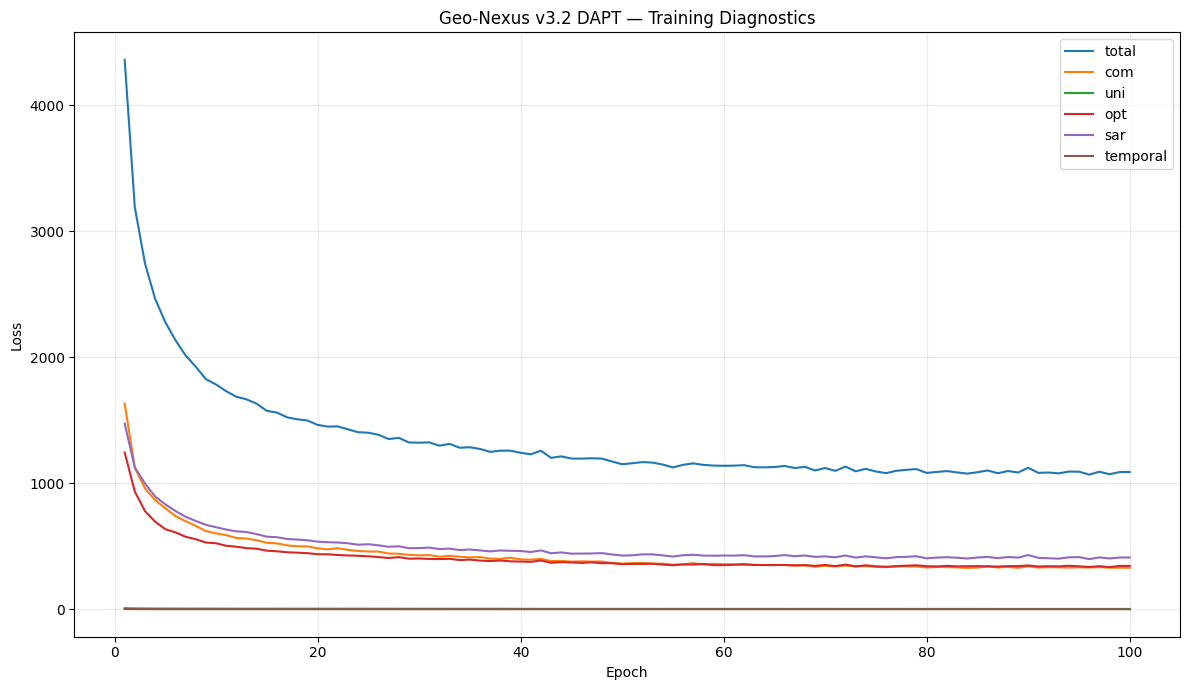

Training curve image saved to: /kaggle/working/geonexus_v3_2_dapt_6664_training_curves.png
Recorded epochs: 100
Last recorded epoch: 100
Measured median epoch time: 00:01:01
Measured cumulative training time: 01:42:47


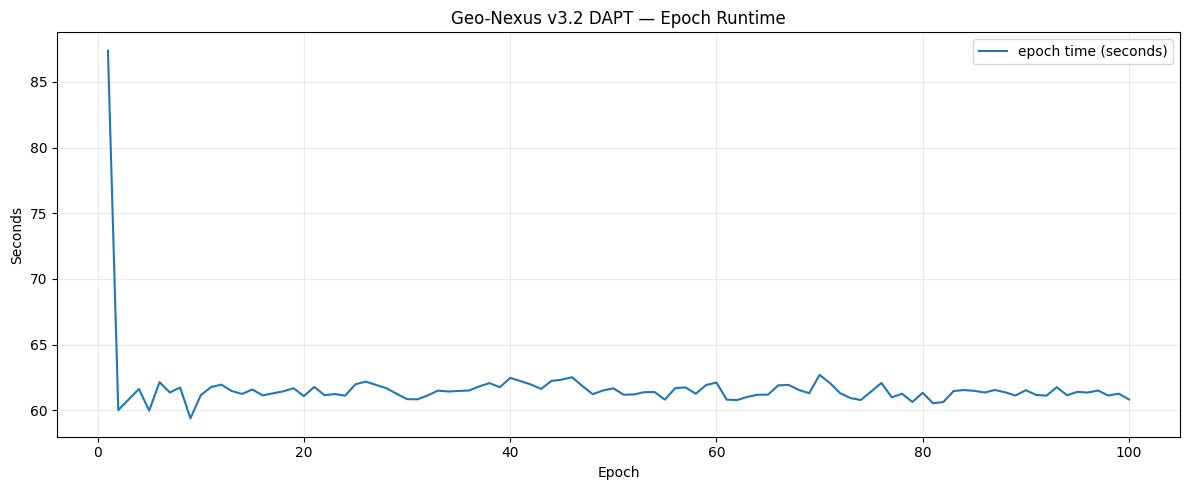

Runtime figure saved to: /kaggle/working/geonexus_v3_2_dapt_6664_epoch_runtime.png
STATUS: 100 epochs recorded.


In [5]:
# ============================================================
# CELL 5 — training curves + runtime diagnostics
# ============================================================

if hist:
    history = hist
elif os.path.exists(HISTORY_FILE):
    with open(
        HISTORY_FILE,
        "r",
        encoding="utf-8",
    ) as f:
        history = json.load(f)
else:
    raise FileNotFoundError(
        "No DAPT history is available yet."
    )

if not history:
    raise RuntimeError(
        "Training history is empty."
    )

epochs = [
    h["epoch"] + 1
    for h in history
]

fig, ax = plt.subplots(
    figsize=(12, 7)
)

for key in [
    "total",
    "com",
    "uni",
    "opt",
    "sar",
    "temporal",
]:
    ax.plot(
        epochs,
        [h[key] for h in history],
        label=key,
    )

ax.set_title(
    "Geo-Nexus v3.2 DAPT — Training Diagnostics"
)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.savefig(
    LOSS_FIGURE,
    dpi=220,
    bbox_inches="tight",
)
plt.show()

print(
    f"Training curve image saved to: "
    f"{LOSS_FIGURE}"
)
print(
    f"Recorded epochs: {len(history)}"
)
print(
    f"Last recorded epoch: "
    f"{history[-1]['epoch'] + 1}"
)

epoch_times = [
    float(
        h.get("epoch_seconds", 0.0)
    )
    for h in history
]

epoch_times = [
    t for t in epoch_times
    if t > 0
]

if epoch_times:

    print(
        "Measured median epoch time: "
        f"{format_seconds(float(np.median(epoch_times[-5:]))) }"
    )

    print(
        "Measured cumulative training time: "
        f"{format_seconds(float(np.sum(epoch_times)))}"
    )

    fig_runtime, ax_runtime = plt.subplots(
        figsize=(12, 5)
    )

    ax_runtime.plot(
        range(
            1,
            len(epoch_times) + 1,
        ),
        epoch_times,
        label="epoch time (seconds)",
    )

    ax_runtime.set_title(
        "Geo-Nexus v3.2 DAPT — Epoch Runtime"
    )
    ax_runtime.set_xlabel("Epoch")
    ax_runtime.set_ylabel("Seconds")
    ax_runtime.grid(alpha=0.25)
    ax_runtime.legend()

    plt.tight_layout()

    runtime_fig = (
        f"/kaggle/working/"
        f"{RUN_TAG}_epoch_runtime.png"
    )

    plt.savefig(
        runtime_fig,
        dpi=220,
        bbox_inches="tight",
    )

    plt.show()

    print(
        f"Runtime figure saved to: "
        f"{runtime_fig}"
    )

print(
    "STATUS: "
    + (
        "100 epochs recorded."
        if len(history) >= CFG["epochs"]
        else
        "DAPT incomplete — latest checkpoint is the recovery artifact."
    )
)


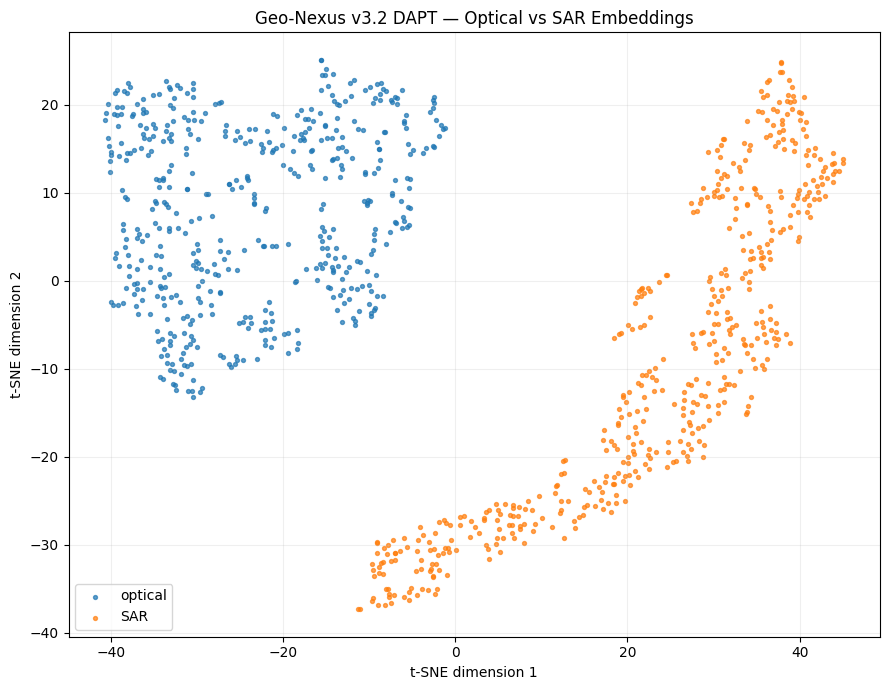

POST-DAPT t-SNE COMPLETE
Embeddings per modality: 500
Saved figure: /kaggle/working/geonexus_v3_2_dapt_6664_tsne.png


In [6]:
# ============================================================
# CELL 6 — post-DAPT t-SNE
# ============================================================

from sklearn.manifold import TSNE

if not os.path.exists(FINAL_ENCODER):

    print(
        "POST-DAPT t-SNE SKIPPED — "
        "final encoder does not exist yet. "
        "The recovery artifact remains available."
    )

else:

    final_state = torch.load(
        FINAL_ENCODER,
        map_location="cpu",
    )

    model.encoder.load_state_dict(
        final_state["encoder"]
    )
    model.eval()

    MAX_EMBEDDINGS_PER_MODALITY = 500

    z_optical = []
    z_sar = []
    collected = 0

    tsne_loader = DataLoader(
        ds,
        batch_size=64,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
        drop_last=False,
    )

    with torch.no_grad():

        for batch in tsne_loader:

            x = batch["x"][:, 0].to(
                DEV,
                non_blocking=True,
            ).float()

            zo, zs = model.project(x)

            remaining = (
                MAX_EMBEDDINGS_PER_MODALITY
                - collected
            )

            if remaining <= 0:
                break

            zo = zo[:remaining]
            zs = zs[:remaining]

            z_optical.append(
                zo.cpu().numpy()
            )
            z_sar.append(
                zs.cpu().numpy()
            )

            collected += zo.shape[0]

            if collected >= (
                MAX_EMBEDDINGS_PER_MODALITY
            ):
                break

    if not z_optical or not z_sar:
        raise RuntimeError(
            "Not enough embeddings were collected for t-SNE."
        )

    zo = np.concatenate(
        z_optical,
        axis=0,
    )
    zs = np.concatenate(
        z_sar,
        axis=0,
    )

    if len(zo) < 2 or len(zs) < 2:
        raise RuntimeError(
            "Not enough embeddings for t-SNE."
        )

    combined = np.concatenate(
        [zo, zs],
        axis=0,
    )

    perplexity = min(
        30,
        max(
            2,
            len(combined) // 3,
        ),
    )

    tsne = TSNE(
        n_components=2,
        random_state=0,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
    )

    emb = tsne.fit_transform(
        combined
    )
    n = len(zo)

    fig, ax = plt.subplots(
        figsize=(9, 7)
    )

    ax.scatter(
        emb[:n, 0],
        emb[:n, 1],
        s=8,
        alpha=0.70,
        label="optical",
    )

    ax.scatter(
        emb[n:, 0],
        emb[n:, 1],
        s=8,
        alpha=0.70,
        label="SAR",
    )

    ax.set_title(
        "Geo-Nexus v3.2 DAPT — Optical vs SAR Embeddings"
    )
    ax.set_xlabel(
        "t-SNE dimension 1"
    )
    ax.set_ylabel(
        "t-SNE dimension 2"
    )
    ax.legend()
    ax.grid(alpha=0.20)

    plt.tight_layout()
    plt.savefig(
        TSNE_FILE,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    print("=" * 78)
    print("POST-DAPT t-SNE COMPLETE")
    print("=" * 78)
    print(
        f"Embeddings per modality: {n}"
    )
    print(
        f"Saved figure: {TSNE_FILE}"
    )


In [7]:
# ============================================================
# CELL 7 — final integrity summary
# ============================================================

import os
import hashlib
from pathlib import Path

def sha256_file(
    path,
    chunk_mb=16,
):

    h = hashlib.sha256()

    with open(
        path,
        "rb",
    ) as f:

        while True:

            chunk = f.read(
                chunk_mb * 1024 * 1024
            )

            if not chunk:
                break

            h.update(chunk)

    return h.hexdigest()


candidate_outputs = [
    CONFIG_FILE,
    CHECKPOINT_MANIFEST,
    HISTORY_FILE,
    HISTORY_CSV,
    PATH_DIAGNOSTIC,
    CHECKPOINT_FLOW_FIGURE,
    LOSS_FIGURE,
    TSNE_FILE,
    FINAL_ENCODER,
    FINAL_ENCODER_STATE,
    FULL_MODEL_FINAL,
    DECUR_FINAL,
]

print("=" * 90)
print("FINAL DAPT ARTIFACT INTEGRITY SUMMARY")
print("=" * 90)

for p in candidate_outputs:

    if os.path.exists(p):

        size_mb = (
            os.path.getsize(p)
            / (1024 ** 2)
        )

        print(
            f"PASS | "
            f"{Path(p).name:55s} | "
            f"{size_mb:10.2f} MiB"
        )

    else:

        print(
            f"SKIP | "
            f"{Path(p).name:55s} | "
            f"not created in this session"
        )

print("\nDAPT state:")
print(
    f"  completed epochs : "
    f"{len(hist)}/{CFG['epochs']}"
)
print(
    f"  completed steps  : "
    f"{len(hist) * STEPS_PER_EPOCH}"
)
print(
    f"  total steps      : "
    f"{TOTAL_TRAINING_STEPS}"
)
print(
    f"  final encoder    : "
    f"{'READY' if os.path.exists(FINAL_ENCODER) else 'PENDING'}"
)

print("\nSHA256 preview:")

for p in candidate_outputs:

    if os.path.exists(p):

        print(
            f"{Path(p).name:55s} "
            f"{sha256_file(p)}"
        )

print(
    "\nNotebook is ready for persistent-artifact packaging."
)


FINAL DAPT ARTIFACT INTEGRITY SUMMARY
PASS | geonexus_v3_2_dapt_6664_config.json                     |       0.00 MiB
PASS | geonexus_v3_2_dapt_6664_checkpoint_status.json          |       0.00 MiB
PASS | geonexus_v3_2_dapt_6664_history.json                    |       0.04 MiB
PASS | geonexus_v3_2_dapt_6664_history.csv                     |       0.02 MiB
PASS | geonexus_v3_2_dapt_6664_path_diagnostic.png             |       0.16 MiB
PASS | geonexus_v3_2_dapt_6664_checkpoint_resume_flow.png      |       0.16 MiB
PASS | geonexus_v3_2_dapt_6664_training_curves.png             |       0.14 MiB
PASS | geonexus_v3_2_dapt_6664_tsne.png                        |       0.35 MiB
PASS | geonexus_v3_2_dapt_6664_encoder_final.pth               |      85.58 MiB
PASS | geonexus_v3_2_dapt_6664_encoder_state_dict.pt           |      85.56 MiB
PASS | geonexus_v3_2_dapt_6664_full_model.pt                   |     157.80 MiB
PASS | geonexus_v3_2_dapt_6664_decur_state_dict.pt             |       0.02 MiB

D

# Persistent artifact package

This package is created at the end of **every session**, including an incomplete session.

### Resume-ready package

Contains:

- latest full training-state checkpoint
- emergency checkpoint when present
- training history (`.json` and `.csv`)
- locked configuration
- checkpoint status
- generated `models/` source
- generated `geonexus_ssl/` source
- environment information
- diagnostics
- notebook source when Kaggle exposes it
- SHA256 manifest

### Complete package after epoch 100

Additionally contains:

- final encoder artifact
- encoder-only `state_dict` `.pt`
- full DAPT model
- standalone DeCUR weights
- final t-SNE diagnostic
- complete run manifest

The package intentionally does not accumulate one large checkpoint file per epoch. The single latest full checkpoint is overwritten after each completed epoch.


In [8]:

# ============================================================
# CELL 8 — persistent artifact packaging
# ============================================================

from pathlib import Path
import os
import json
import shutil
import hashlib
import platform
import sys
import time

ARTIFACT_ROOT = Path(ARTIFACT_ROOT)

CHECKPOINTS_DIR = ARTIFACT_ROOT / "checkpoints"
MODEL_DIR = ARTIFACT_ROOT / "models"
SOURCE_DIR = ARTIFACT_ROOT / "source"
DIAGNOSTICS_DIR = ARTIFACT_ROOT / "diagnostics"
METADATA_DIR = ARTIFACT_ROOT / "metadata"

for directory in [
    CHECKPOINTS_DIR,
    MODEL_DIR,
    SOURCE_DIR,
    DIAGNOSTICS_DIR,
    METADATA_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


def copy_if_exists(src, dst):
    src = Path(src)
    dst = Path(dst)

    if not src.exists():
        return False

    dst.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    if src.resolve() != dst.resolve():
        shutil.copy2(src, dst)

    return True


# Recovery checkpoints.
for checkpoint_path in [
    CKPT,
    EMERGENCY_CKPT,
    LEGACY_CKPT,
    LEGACY_RESUME_CKPT,
]:
    copy_if_exists(
        checkpoint_path,
        CHECKPOINTS_DIR
        / Path(checkpoint_path).name,
    )


# Final model artifacts.
for model_path in [
    FINAL_ENCODER,
    FINAL_ENCODER_STATE,
    FULL_MODEL_FINAL,
    DECUR_FINAL,
]:
    copy_if_exists(
        model_path,
        MODEL_DIR
        / Path(model_path).name,
    )


# Metadata.
for metadata_path in [
    CONFIG_FILE,
    CHECKPOINT_MANIFEST,
    HISTORY_FILE,
    HISTORY_CSV,
]:
    copy_if_exists(
        metadata_path,
        METADATA_DIR
        / Path(metadata_path).name,
    )


# Diagnostics.
for diagnostic_path in [
    PATH_DIAGNOSTIC,
    CHECKPOINT_FLOW_FIGURE,
    LOSS_FIGURE,
    TSNE_FILE,
    f"/kaggle/working/{RUN_TAG}_epoch_runtime.png",
]:
    copy_if_exists(
        diagnostic_path,
        DIAGNOSTICS_DIR
        / Path(diagnostic_path).name,
    )


# Generated source package.
for package_name in [
    "models",
    "geonexus_ssl",
]:

    source_root = (
        Path("/kaggle/working")
        / package_name
    )

    if not source_root.exists():
        continue

    for source_file in source_root.rglob("*"):

        if (
            not source_file.is_file()
            or "__pycache__"
            in source_file.parts
        ):
            continue

        if source_file.suffix.lower() not in {
            ".py",
            ".json",
            ".yaml",
            ".yml",
            ".md",
        }:
            continue

        relative = source_file.relative_to(
            source_root
        )

        copy_if_exists(
            source_file,
            SOURCE_DIR
            / package_name
            / relative,
        )


# Notebook source exposed by Kaggle.
notebook_source = Path(
    "/kaggle/working/"
    ".virtual_documents/"
    "__notebook_source__.ipynb"
)

if notebook_source.exists():

    copy_if_exists(
        notebook_source,
        SOURCE_DIR
        / "executed_notebook_source.ipynb",
    )


# Environment manifest.
environment = {
    "python": sys.version,
    "platform": platform.platform(),
    "torch": torch.__version__,
    "numpy": np.__version__,
    "cuda_available":
        bool(torch.cuda.is_available()),
    "cuda_runtime":
        (
            torch.version.cuda
            if torch.cuda.is_available()
            else None
        ),
    "cudnn":
        (
            torch.backends.cudnn.version()
            if torch.cuda.is_available()
            else None
        ),
    "gpu_count":
        int(torch.cuda.device_count()),
    "gpus": [
        torch.cuda.get_device_name(i)
        for i in range(
            torch.cuda.device_count()
        )
    ],
    "dataset_root": str(DATA_ROOT),
    "weights_root": str(WEIGHTS_ROOT),
    "project_repository":
        PROJECT_GITHUB_URL,
}

with open(
    METADATA_DIR / "environment.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        environment,
        f,
        indent=2,
    )


artifact_complete = (
    len(hist) >= CFG["epochs"]
    and os.path.exists(FINAL_ENCODER)
)

artifact_manifest = {
    "project":
        "Geo-Nexus v3.2",
    "run_tag":
        RUN_TAG,
    "status":
        (
            "complete"
            if artifact_complete
            else "resume-ready"
        ),
    "epochs_completed":
        len(hist),
    "epochs_target":
        CFG["epochs"],
    "pune_pairs":
        3315,
    "satara_pairs":
        3349,
    "total_pairs":
        6664,
    "patch_size":
        CFG["patch_size"],
    "input_channels":
        CFG["input_channels"],
    "batch_size":
        CFG["batch_size"],
    "steps_per_epoch":
        STEPS_PER_EPOCH,
    "total_training_steps":
        TOTAL_TRAINING_STEPS,
    "checkpoint_policy":
        "overwrite latest full checkpoint after every completed epoch",
    "training_wall_hours":
        TRAINING_WALL_HOURS,
    "post_train_reserve_minutes":
        POST_TRAIN_RESERVE_MINUTES,
    "resume_checkpoint":
        (
            Path(CKPT).name
            if os.path.exists(CKPT)
            else None
        ),
    "emergency_checkpoint":
        (
            Path(EMERGENCY_CKPT).name
            if os.path.exists(
                EMERGENCY_CKPT
            )
            else None
        ),
    "final_encoder":
        (
            Path(FINAL_ENCODER).name
            if os.path.exists(
                FINAL_ENCODER
            )
            else None
        ),
    "full_model":
        (
            Path(FULL_MODEL_FINAL).name
            if os.path.exists(
                FULL_MODEL_FINAL
            )
            else None
        ),
    "decur_state":
        (
            Path(DECUR_FINAL).name
            if os.path.exists(
                DECUR_FINAL
            )
            else None
        ),
    "project_repository":
        PROJECT_GITHUB_URL,
    "created_utc":
        time.strftime(
            "%Y-%m-%dT%H:%M:%SZ",
            time.gmtime(),
        ),
}

with open(
    METADATA_DIR / "artifact_manifest.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        artifact_manifest,
        f,
        indent=2,
    )

(
    METADATA_DIR
    / "project_repository.txt"
).write_text(
    PROJECT_GITHUB_URL + "\n",
    encoding="utf-8",
)


# README.
readme = f"""
# Geo-Nexus v3.2 DAPT Artifact Release

Status: {"COMPLETE" if artifact_complete else "RESUME-READY"}

DAPT corpus:
- Pune: 3315 pairs
- Satara: 3349 pairs
- Total: 6664 pairs

Architecture:
- Patch: 128 x 128
- Channels: 17
- Epochs target: 100
- Batch size: 96
- AMP: enabled
- Backbone LR: 3e-5
- Head LR: 3e-4
- Warm-up: 5 epochs
- Schedule: linear warm-up + cosine decay
- DeCUR projection dimension: 2048
- DeCUR common ratio: 0.875
- DeCUR lambda: 0.0051
- Temporal tau: 0.1
- Temporal gamma: 0.3
- DeCUR loss weight: 1.0
- Temporal loss weight: 0.5
- Synthetic occlusion probability: 0.5
- Maximum synthetic cloud fraction: 0.7

Recovery:
- Latest full checkpoint is overwritten after every completed epoch.
- Emergency checkpoint is saved at the training wall-clock guard.
- The next session attaches this private artifact Dataset as Input.
- The notebook recursively selects the highest compatible completed epoch.

Complete-run artifacts:
- final encoder
- encoder state_dict
- full DAPT model
- DeCUR state
- history
- diagnostics
- source
- environment metadata
- SHA256 manifest

Project repository:
{PROJECT_GITHUB_URL}
""".strip() + "\n"

(
    ARTIFACT_ROOT / "README.md"
).write_text(
    readme,
    encoding="utf-8",
)


def sha256_artifact(path):
    h = hashlib.sha256()

    with open(
        path,
        "rb",
    ) as f:
        while True:
            chunk = f.read(
                16 * 1024 * 1024
            )
            if not chunk:
                break
            h.update(chunk)

    return h.hexdigest()


artifact_files = sorted(
    p
    for p in ARTIFACT_ROOT.rglob("*")
    if p.is_file()
)

sha256_manifest = {}

for artifact_file in artifact_files:
    sha256_manifest[
        str(
            artifact_file.relative_to(
                ARTIFACT_ROOT
            )
        )
    ] = {
        "sha256":
            sha256_artifact(
                artifact_file
            ),
        "bytes":
            artifact_file.stat().st_size,
    }

with open(
    ARTIFACT_ROOT
    / "metadata"
    / "SHA256SUMS.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        sha256_manifest,
        f,
        indent=2,
    )


dataset_metadata = {
    "title":
        "Geo-Nexus v3.2 DAPT Artifacts",
    "subtitle":
        "Persistent DAPT checkpoints and trained model artifacts",
    "description":
        (
            "Private Geo-Nexus v3.2 DAPT artifact release. "
            "Contains epoch-resume checkpoints, final model artifacts "
            "when available, DeCUR state, training history, diagnostics, "
            "generated source modules, environment metadata and SHA256 "
            "integrity records. Internal research artifact."
        ),
    "id":
        ARTIFACT_DATASET_ID,
    "licenses":
        [
            {"name": "unknown"}
        ],
}

with open(
    ARTIFACT_ROOT
    / "dataset-metadata.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        dataset_metadata,
        f,
        indent=2,
    )


artifact_files = sorted(
    p
    for p in ARTIFACT_ROOT.rglob("*")
    if p.is_file()
)

artifact_bytes = sum(
    p.stat().st_size
    for p in artifact_files
)

print("=" * 90)
print("PERSISTENT ARTIFACT PACKAGE READY")
print("=" * 90)
print(
    "Status:",
    (
        "COMPLETE"
        if artifact_complete
        else "RESUME-READY"
    )
)
print(
    "Epochs:",
    f"{len(hist)}/{CFG['epochs']}"
)
print(
    "Files:",
    len(artifact_files)
)
print(
    "Size:",
    f"{artifact_bytes / (1024**3):.3f} GiB"
)
print(
    "Artifact root:",
    ARTIFACT_ROOT
)
print(
    "Kaggle Dataset:",
    ARTIFACT_DATASET_ID
)
print(
    "\nPERSISTENT PACKAGE AUDIT: PASS"
)


PERSISTENT ARTIFACT PACKAGE READY
Status: COMPLETE
Epochs: 100/100
Files: 31
Size: 0.784 GiB
Artifact root: /kaggle/working/geonexus_v3_2_dapt_6664_artifact_release
Kaggle Dataset: sumit07125/geonexus-v3-2-dapt-6664-artifacts

PERSISTENT PACKAGE AUDIT: PASS


In [9]:

# ============================================================
# CELL 9 — publish / update the private Kaggle artifact Dataset
# ============================================================

import shutil
import subprocess
from pathlib import Path

DATASET_ID = ARTIFACT_DATASET_ID
DATASET_ROOT = Path(
    ARTIFACT_ROOT
)

kaggle_exe = shutil.which(
    "kaggle"
)

if kaggle_exe is None:
    raise RuntimeError(
        "Kaggle CLI is not installed. "
        "Run `pip install -U kaggle`."
    )

print("=" * 90)
print(
    "PUBLISHING PERSISTENT GEONEXUS ARTIFACT DATASET"
)
print("=" * 90)
print(
    f"Dataset: {DATASET_ID}"
)

status = subprocess.run(
    [
        kaggle_exe,
        "datasets",
        "status",
        DATASET_ID,
    ],
    text=True,
    capture_output=True,
)

dataset_exists = (
    status.returncode == 0
)

if dataset_exists:

    print(
        "Existing private Dataset detected."
    )

    upload_cmd = [
        kaggle_exe,
        "datasets",
        "version",
        "-p",
        str(DATASET_ROOT),
        "-m",
        (
            "Geo-Nexus v3.2 DAPT "
            f"{len(hist)}/{CFG['epochs']} epochs"
        ),
        "--dir-mode",
        "zip",
    ]

else:

    print(
        "Dataset not found. "
        "Creating a new private Dataset."
    )

    upload_cmd = [
        kaggle_exe,
        "datasets",
        "create",
        "-p",
        str(DATASET_ROOT),
        "--dir-mode",
        "zip",
    ]

print(
    "\n$",
    " ".join(upload_cmd),
)

result = subprocess.run(
    upload_cmd,
    text=True,
)

if result.returncode != 0:

    raise RuntimeError(
        "Kaggle artifact Dataset upload failed. "
        "The local artifact package remains at:\n"
        f"{DATASET_ROOT}"
    )

print(
    "\n" + "=" * 90
)
print(
    "KAGGLE ARTIFACT DATASET PUBLISHED"
)
print(
    "=" * 90
)
print(
    f"Dataset ID : {DATASET_ID}"
)
print(
    "URL        : "
    f"https://www.kaggle.com/datasets/"
    f"{DATASET_ID}"
)
print(
    "\nThe next DAPT session can attach this Dataset "
    "and resume from the highest completed epoch."
)


PUBLISHING PERSISTENT GEONEXUS ARTIFACT DATASET
Dataset: sumit07125/geonexus-v3-2-dapt-6664-artifacts
Dataset not found. Creating a new private Dataset.

$ /usr/local/bin/kaggle datasets create -p /kaggle/working/geonexus_v3_2_dapt_6664_artifact_release --dir-mode zip
Starting upload for file metadata.zip


100%|██████████| 24.3k/24.3k [00:00<00:00, 92.0kB/s]


Upload successful: metadata.zip (24KB)
Starting upload for file checkpoints.zip


100%|██████████| 434M/434M [00:04<00:00, 106MB/s] 
  0%|          | 0.00/790k [00:00<?, ?B/s]

Upload successful: checkpoints.zip (434MB)
Starting upload for file diagnostics.zip


...

Upload successful: source.zip (36KB)
Starting upload for file README.md


100%|██████████| 1.11k/1.11k [00:00<00:00, 4.48kB/s]


Upload successful: README.md (1KB)
Starting upload for file models.zip


100%|██████████| 305M/305M [00:03<00:00, 95.2MB/s]


Upload successful: models.zip (305MB)
Your private Dataset is being created. Please check progress at https://www.kaggle.com/datasets/sumit07125/geonexus-v3-2-dapt-6664-artifacts

KAGGLE ARTIFACT DATASET PUBLISHED
Dataset ID : sumit07125/geonexus-v3-2-dapt-6664-artifacts
URL        : https://www.kaggle.com/datasets/sumit07125/geonexus-v3-2-dapt-6664-artifacts

The next DAPT session can attach this Dataset and resume from the highest completed epoch.


# DAPT session completion report

At the end of each session, this notebook produces one of two states.

### `RESUME-READY`

DAPT has not reached 100 epochs yet.

The private Kaggle artifact Dataset contains the latest complete training-state checkpoint and the metadata/source required for recovery.

### `COMPLETE`

DAPT has reached 100 epochs.

The private Kaggle artifact Dataset additionally contains the final encoder, encoder-only state dict, full DAPT model, DeCUR state, final diagnostics, environment metadata, source package, and SHA256 manifest.

## Reviewer-visible evidence

- exact 6,664-pair gate
- foundation-weight shape gates
- stem-surgery cosine gate
- 17-channel batch gate
- finite DeCUR loss
- finite temporal loss
- epoch-by-epoch timing
- percentage progress
- remaining epochs
- remaining optimizer steps
- estimated remaining training time
- projected finish time
- wall-clock time remaining
- automatic highest-epoch resume
- persistent artifact Dataset publication/update
- SHA256 artifact integrity
- final encoder and complete model artifacts after epoch 100

## Dataset separation

- `sumit07125/geonexus-mh-v3` — DAPT training data
- `sumit07125/ssl4eo-weights` — foundation weights
- `sumit07125/oscd-onera-v1` — OSCD prepared dataset
- `sumit07125/geonexus-v3-2-dapt-6664-artifacts` — this run's persistent training/model artifacts
